# 28 · GAN: 판별기의 분류 손실을 생성기가 거꾸로 타고 오르기

**이번 질문:** 밀도를 전혀 쓰지 않고 샘플만 내는 모델은 무엇으로 학습할까요? 두 신경망의 목적이 서로 반대일 때 미분과 갱신은 어떻게 나뉠까요?

23번의 혼합 모형은 밀도 $p(x)$를 닫힌식으로 썼고, 뒤에 올 32번의 score 모델은 밀도의 기울기를 배웁니다. 둘 다 "이 점이 얼마나 그럴듯한가"를 숫자로 내놓습니다.
이번 모델은 그런 숫자를 아예 내놓지 않습니다. **생성기** $G$는 잡음 $z$를 받아 표본 $\hat x=G(z)$를 낼 뿐이고, 얼마나 그럴듯한지는 **판별기** $D$라는 두 번째 신경망이 분류 문제로 대신 말해 줍니다.
판별기는 02번의 BCE를 내리고, 생성기는 **같은 손실을 거꾸로 타고 올라** 판별기를 속이는 방향으로 움직입니다. 두 목적이 반대라서, 어떤 기울기를 누구에게 주고 무엇을 버리는지가 이 노트북의 핵심입니다.

- 준비물: [03](../00_기초/03_perceptron_to_mlp.ipynb)의 MLP forward·backward(특히 backward가 돌려주는 입력 기울기 $dX$), [02](../00_기초/02_probability_and_losses.ipynb)의 BCE와 logit 기울기, [04](../00_기초/04_optimizers.ipynb)의 Adam, [13](../02_연결/13_autodiff.ipynb)의 stop-gradient, [23](23_latent_mixture_em.ipynb)의 혼합 샘플·책임확률, [11](../02_연결/11_linear_algebra.ipynb)의 PCA.
- 도착점: $D$와 $G$를 손 backward로 만들고 생성기의 기울기가 판별기를 지나오는 경로를 수치미분으로 검산한 뒤, 1차원·2차원 혼합과 MNIST PCA 좌표에서 교대 갱신을 실행합니다.
- 다음 연결: 29번(설계만)의 WGAN·gradient penalty는 기울기의 기울기가 필요해 13번의 자동미분 엔진이나 PyTorch로 넘어갑니다. 밀도를 쓰지 않는 또 다른 길은 [32 score](32_score_matching.ipynb)입니다.

### 읽는 법

| 표시 | 뜻 | 어떻게 읽나 |
|---|---|---|
| 🔑 **핵심** | 수식·규칙·코드. 이 노트북이 가르치려는 것 | 남에게 설명할 수 있을 때까지 읽고, 코드를 가리고 다시 써 봅니다 |
| 🔍 **확인** | 검산 결과와 그림의 해석 | 실행해서 눈으로 보고 넘어갑니다. 외울 것은 없습니다 |
| 📎 **참고** | 배경 지식, 환경, 용어의 유래 | 처음 읽을 때는 건너뛰어도 됩니다 |
| ✏️ **연습** | 직접 바꿔 보는 문제 | 손으로 먼저 예상한 뒤 실행합니다 |

새 용어는 처음 나오는 자리에서 **용어** 상자로 한 줄씩 풀이합니다.

**이 노트북에서 반드시 가져갈 세 가지**

1. 판별기의 손실은 "진짜=1, 가짜=0" 두 항의 BCE이고, 생성기는 그 반대 방향으로 움직입니다. 학습 초기($D(G(z))\approx0$)에는 원래 식 $\log(1-D(G(z)))$의 기울기 $-p$가 거의 0이라, 실제로는 $-\log D(G(z))$의 기울기 `-(1 - p)`를 씁니다.
2. 생성기의 기울기는 판별기의 backward가 돌려준 **입력 기울기**에서 출발합니다. `dx_fake, _ = mlp_backward(d_logit, d_params, cache_d)` 한 줄로 받아 생성기 출력의 상류 기울기로 넘기고, 같이 계산된 판별기 파라미터 기울기는 버립니다.
3. 생성기를 고정하면 판별기의 최적해는 $D^*(x)=p_{data}(x)/(p_{data}(x)+p_g(x))$이고, 두 분포가 같아지는 균형점에서 $L_D=2\log2$, $L_G=\log2$입니다. 생성 샘플을 봉우리별로 세면 `np.bincount(labels, minlength=2)`로 mode 붕괴가 숫자로 보입니다.

[전체 학습 경로](../../docs/CURRICULUM.md) · [글 규칙](../../docs/WRITING.md) · [그림 설계](../../docs/DESIGN.md) · [그림 보조 코드](../../src/utils/gan_plots.py)

In [1]:
# 준비 셀: 실행만 하고 넘어가도 됩니다.
# 1) 프로젝트 루트를 import 경로에 넣습니다. 노트북을 어느 폴더에서 열어도 src/를 찾기 위해서입니다.
import sys
from pathlib import Path
project_root = next(p for p in (Path.cwd(), *Path.cwd().parents)          # 현재 폴더부터 위로 올라가며
                    if (p / "src/utils/plotting.py").is_file())            # src/utils/plotting.py가 있는 첫 폴더를 고릅니다
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

# 2) NumPy, 수치미분 도우미(2절부터: 중심차분 numerical_gradient와 상대오차 rel_error), 연습 검사 도우미, 데이터 로더, 이 노트북의 그림 함수(src/utils/gan_plots.py)
import numpy as np
from src.utils import setup_plots
from src.utils.gradcheck import numerical_gradient, rel_error
from src.utils import run_check
from src.data.mnist import load_mnist, load_examples
from src.utils.gan_plots import (
    plot_curves, plot_generated_images, plot_generator_losses, plot_gan_paths, plot_optimal_discriminator,
    plot_discriminator_fit, plot_gan_1d, plot_mode_counting, plot_mode_coverage,
    plot_pca_roundtrip, plot_digit_counts, plot_variant_bars,
)

# 3) 그림 설정. 배열 출력은 소수 4자리로 줄여 읽기 쉽게 합니다.
setup_plots()
np.set_printoptions(precision=4, suppress=True)
print("NumPy", np.__version__, "· GAN 준비 완료")

NumPy 2.4.6 · GAN 준비 완료


### 📎 이 노트북의 예시: 1차원 두 봉우리 혼합, 2차원 혼합, MNIST PCA-32 좌표

- **1차원 두 봉우리 혼합.** 23번의 공통 상황입니다. 비율 $\pi=(0.3,0.7)$, 평균 $\mu=(-2,2)$, 표준편차 $\sigma=(0.5,1)$인 두 Gaussian을 섞은 분포입니다. 진짜 밀도를 닫힌식으로 알기 때문에 3절에서 **최적 판별기**를 직접 그려 학습 결과와 맞춰 볼 수 있습니다. GAN 자신은 이 밀도를 전혀 쓰지 않고 샘플만 봅니다.
- **2차원 혼합.** 같은 규약의 2차원 판입니다. 생성 샘플이 두 봉우리를 모두 덮는지 산점도로 보이고, 책임확률로 봉우리를 배정해 세면 4절의 mode 붕괴가 개수로 나옵니다.
- **MNIST PCA-32 좌표.** 손글씨 숫자 이미지 데이터입니다. 앞 5,000장을 11번의 PCA로 32개 좌표로 줄여 그 좌표 공간에서 학습하고, 생성한 좌표를 다시 28×28 이미지로 되돌립니다(5절).

> **용어**
>
> - **생성 모형(generative model)**: 데이터와 비슷한 새 표본을 만들어 내는 모델. 밀도 $p(x)$를 쓰는 종류(23·32번)와, 이 노트북처럼 **샘플만** 내는 종류가 있습니다.
> - **혼합(mixture) 분포**: 성분 $k$를 비율 $\pi_k$로 고른 뒤 그 Gaussian에서 점을 뽑는 분포. 밀도는 $p(x)=\sum_k\pi_k\mathcal N(x;\mu_k,\sigma_k^2)$입니다 (23번 1절).
> - **책임확률(responsibility)** $r_k(x)=p(z=k\mid x)$: 점 $x$가 성분 $k$에서 왔을 확률. 성분별 로그 항의 softmax입니다 (23번 2절).
> - **MNIST**: 0–9 손글씨 숫자를 28×28 흑백 이미지로 담은 데이터셋. 화소 값은 0(흰 종이)–1(검은 잉크)입니다. 이 노트북에서는 앞 5,000장만 씁니다.

아래 네 셀은 실행만 하고 넘어가도 됩니다. 23번에서 유도한 함수 중 이 노트북이 쓰는 것만 짧게 다시 정의하고 마지막 셀에서 검산합니다.

> **코드**
>
> - `x[:, None]`: `(N,)`을 `(N, 1)`로 세워 `(2,)`짜리 성분 배열과 브로드캐스팅합니다. 결과는 `(N, 2)` = 점마다 성분 두 개.
> - `terms.max(axis=1, keepdims=True)`: 행마다 최댓값을 `(N, 1)`로 남겨 빼기 쉽게 합니다. 지수가 넘치지 않게 하는 02번 8절의 안정화입니다.
> - `rng.choice(2, size=n, p=MIX_PI)`: 0 또는 1을 확률 `MIX_PI`로 n번 뽑습니다. 잠재 성분을 먼저 고르는 23번 5절의 ancestral sampling입니다.
> - `np.linalg.solve(C, d.T).T`: 관측마다 $C^{-1}d$를 한 번에 (12번 2절). `np.linalg.slogdet(C)[1]`은 $\log\det C$입니다.
> - `np.einsum("nij,nj->ni", L[z], eps)`: 점마다 다른 행렬 `L[z]`를 그 점의 벡터에 곱합니다. 첨자 `n`은 점, `ij`는 행렬, `j`가 합쳐지는 축입니다.

In [2]:
MIX_PI = np.array([0.3, 0.7])                                        # (2,): 1차원 성분 비율 π_k
MIX_MU = np.array([-2.0, 2.0])                                       # (2,): 성분 평균 μ_k
MIX_SIGMA = np.array([0.5, 1.0])                                     # (2,): 성분 표준편차 σ_k
MIX2_PI = np.array([0.4, 0.6])                                       # (2,): 2차원 혼합의 비율
MIX2_MU = np.array([[-2.0, 0.0], [2.0, 1.0]])                        # (2, 2): 성분 평균 (행 = 성분)
MIX2_COV = np.array([[[0.6, 0.2], [0.2, 0.5]], [[0.4, -0.1], [-0.1, 0.8]]])   # (2, 2, 2): 성분 공분산 Σ_k
print("1차원 π, μ, σ:", MIX_PI, MIX_MU, MIX_SIGMA, "· 2차원 평균", MIX2_MU.tolist())

1차원 π, μ, σ: [0.3 0.7] [-2.  2.] [0.5 1. ] · 2차원 평균 [[-2.0, 0.0], [2.0, 1.0]]


In [3]:
def mix_log_terms(x):
    """1차원 성분별 log π_k + log N(x; μ_k, σ_k²) (23번 1절). x: (N,) → (N, 2)."""
    squared = (x[:, None] - MIX_MU) ** 2 / MIX_SIGMA ** 2            # (N, 2): 표준화한 제곱 거리
    return np.log(MIX_PI) - 0.5 * (np.log(2 * np.pi * MIX_SIGMA ** 2) + squared)


def mix_logpdf(x):
    """23번 1절: log p(x) = logsumexp_k [성분별 로그 항]. x: (N,) → (N,)."""
    terms = mix_log_terms(x)
    biggest = terms.max(axis=1, keepdims=True)                       # (N, 1): 행마다 최댓값 (안정화)
    return (biggest + np.log(np.exp(terms - biggest).sum(axis=1, keepdims=True)))[:, 0]


def mix_responsibility(x):
    """23번 2절: r_k(x) = 로그 항의 softmax. x: (N,) → (N, 2), 행 합 1."""
    terms = mix_log_terms(x)
    shifted = np.exp(terms - terms.max(axis=1, keepdims=True))       # (N, 2)
    return shifted / shifted.sum(axis=1, keepdims=True)


def mix_sample(n, rng):
    """23번 5절 ancestral sampling: z ~ π 를 뽑고 x ~ N(μ_z, σ_z²). n: 개수 → (n,)."""
    z = rng.choice(2, size=n, p=MIX_PI)                              # (n,): 성분 번호
    return MIX_MU[z] + MIX_SIGMA[z] * rng.normal(size=n)

In [4]:
def mix2_log_terms(X):
    """2차원 성분별 log π_k + log N(x; μ_k, Σ_k) (23번 1절, 12번 2절의 로그 밀도). X: (N, 2) → (N, 2)."""
    terms = np.zeros((len(X), 2))
    for k in range(2):
        difference = X - MIX2_MU[k]                                  # (N, 2): x − μ_k
        squared = np.sum(difference * np.linalg.solve(MIX2_COV[k], difference.T).T, axis=1)   # (N,): 마할라노비스 거리²
        terms[:, k] = np.log(MIX2_PI[k]) - 0.5 * (2 * np.log(2 * np.pi) + np.linalg.slogdet(MIX2_COV[k])[1] + squared)
    return terms


def mix2_responsibility(X):
    """2차원 혼합의 책임확률 (23번 2절). X: (N, 2) → (N, 2), 행 합 1."""
    terms = mix2_log_terms(X)
    shifted = np.exp(terms - terms.max(axis=1, keepdims=True))
    return shifted / shifted.sum(axis=1, keepdims=True)


def mix2_sample(n, rng):
    """2차원 ancestral sampling: z ~ π, x = μ_z + ε L_zᵀ (12번 1절의 Cholesky). n: 개수 → (n, 2)."""
    z = rng.choice(2, size=n, p=MIX2_PI)                             # (n,): 성분 번호
    epsilon = rng.normal(size=(n, 2))                                # (n, 2): 독립 표준정규
    L = np.linalg.cholesky(MIX2_COV)                                 # (2, 2, 2): 성분마다 Σ_k = L_k L_kᵀ
    return MIX2_MU[z] + np.einsum("nij,nj->ni", L[z], epsilon)

In [5]:
mix_grid = np.linspace(-12, 12, 24001)                               # (24001,): 적분 확인용 격자
np.testing.assert_allclose(np.trapezoid(np.exp(mix_logpdf(mix_grid)), mix_grid), 1.0, atol=1e-8)   # 검산: 밀도의 적분 = 1
np.testing.assert_allclose(mix_responsibility(mix_grid).sum(axis=1), 1.0)                          # 검산: 책임확률 행 합 = 1
mix_check = mix_sample(20000, np.random.default_rng(23))             # (20000,): 표본 평균을 닫힌식과 맞춰 보기
np.testing.assert_allclose(mix_check.mean(), MIX_PI @ MIX_MU, atol=0.05)                           # 검산: 표본 평균 ≈ Σ π_k μ_k = 0.8
mix2_check = mix2_sample(20000, np.random.default_rng(23))           # (20000, 2)
np.testing.assert_allclose(mix2_check.mean(axis=0), MIX2_PI @ MIX2_MU, atol=0.05)                  # 검산: 2차원 표본 평균 ≈ Σ π_k μ_k
print("밀도 적분 1 · 20,000개 표본 평균", mix_check.mean().round(3), "(닫힌식 0.8) · 2차원", mix2_check.mean(axis=0).round(3))

밀도 적분 1 · 20,000개 표본 평균 0.782 (닫힌식 0.8) · 2차원 [0.387 0.587]


## 🔑 1. 두 모델, 두 목적: 판별기는 내려가고 생성기는 거슬러 오릅니다

**이 절에서 가져갈 것:** 판별기 $D$는 "진짜=1, 가짜=0"인 두 항의 BCE를 내리고, 생성기 $G$는 같은 점수를 반대로 올립니다. 올리는 식이 두 가지인데, $\log(1-D(G(z)))$를 내리는 원래(minimax) 식은 $D(G(z))\approx0$인 학습 초기에 기울기가 거의 0이고, $-\log D(G(z))$를 내리는 non-saturating 식은 바로 그 자리에서 기울기가 가장 큽니다.

위조지폐를 만드는 쪽과 감별하는 쪽을 함께 학습시킨다고 생각해 봅니다. 감별사는 진짜 지폐와 위조지폐를 놓고 "진짜인가"를 맞히는 **분류 문제**를 풉니다. 위조범은 감별사의 답을 보고 "진짜라고 하게 만드는" 방향으로 지폐를 고칩니다.
여기서 지폐는 1차원 혼합에서 뽑은 숫자 하나이고, 감별사는 숫자 하나를 받아 점수 하나를 내는 작은 신경망입니다.

> **용어**
>
> - **생성기(generator)** $G$: 잠재 벡터 $z$를 받아 표본 $\hat x=G(z)$를 내는 신경망. 밀도를 내지 않고 표본만 냅니다.
> - **잠재 벡터(latent vector)** $z$: 표준정규 $\mathcal N(0,I)$에서 뽑는 잡음. 생성기의 입력이며, 이 잡음의 무작위성이 생성 표본의 다양성이 됩니다.
> - **판별기(discriminator)** $D$: 표본을 받아 "진짜일 확률"을 내는 신경망. 마지막 층은 실수 하나(**logit** $a$)를 내고 $D(x)=\sigma(a)$로 확률이 됩니다 (02번 7절).
> - **softplus** $\operatorname{softplus}(t)=\log(1+e^t)$: $-\log\sigma(a)=\operatorname{softplus}(-a)$, $-\log(1-\sigma(a))=\operatorname{softplus}(a)$입니다. 지수가 넘치지 않는 안정한 BCE 계산이며 코드에서는 `np.logaddexp(0, t)`입니다.
> - **포화(saturation)**: 손실 곡선이 평평해져 기울기가 0에 가까워지는 자리. 기울기가 없으면 갱신도 없습니다.
> - **minimax(최소최대) 목적** $\min_G\max_D V(D,G)$: 값 $V$ 하나를 두고 $D$ 는 올리고 $G$ 는 내리는 형태. 원논문의 식이며, 이 노트북에서는 $D$ 가 $L_D=-V$ 를 내리고 $G$ 가 $V$ 의 둘째 항인 $L_G^{mm}$ 을 내리는 두 방향으로 나타납니다.

진짜 표본 $N$개의 logit을 $a^{real}\in\mathbb R^{N\times1}$, 가짜 표본 $M$개의 logit을 $a^{fake}\in\mathbb R^{M\times1}$라 두면 판별기의 손실은 02번 7절 BCE의 두 항입니다.

$$L_D=\frac1N\sum_{n=0}^{N-1}\operatorname{softplus}(-a^{real}_n)\;+\;\frac1M\sum_{m=0}^{M-1}\operatorname{softplus}(a^{fake}_m).$$

첫 항은 진짜에 정답 1을, 둘째 항은 가짜에 정답 0을 준 $-\log$ 우도입니다. logit에 대한 미분도 02번 7절 그대로입니다.

$$\frac{\partial L_D}{\partial a^{real}_n}=\frac{\sigma(a^{real}_n)-1}{N},\qquad
\frac{\partial L_D}{\partial a^{fake}_m}=\frac{\sigma(a^{fake}_m)}{M}.$$

생성기는 둘째 항을 **거꾸로** 밉니다. 원래 논문의 minimax 식과 실제로 쓰는 non-saturating 식을 $p_m=\sigma(a^{fake}_m)$로 적으면

$$L_G^{mm}=\frac1M\sum_m\log(1-p_m)=-\frac1M\sum_m\operatorname{softplus}(a^{fake}_m),\qquad
L_G^{ns}=\frac1M\sum_m\operatorname{softplus}(-a^{fake}_m),$$

$$\frac{\partial L_G^{mm}}{\partial a^{fake}_m}=\frac{-p_m}{M},\qquad
\frac{\partial L_G^{ns}}{\partial a^{fake}_m}=\frac{-(1-p_m)}{M}.$$

두 기울기 모두 음수라 "logit을 키우는" 같은 방향이지만 **크기**가 다릅니다. 학습 초기에는 판별기가 쉽게 이겨서 $p\approx0$인데, 그 자리에서 minimax의 크기는 $p$이고 non-saturating의 크기는 $1-p$입니다.
$p=0.01$, 표본 하나($M=1$)라면 $-0.01$과 $-0.99$로 **99배** 차이입니다. 아래 셀에서 두 곡선과 두 기울기를 그려 확인합니다.

In [6]:
loss_p = np.linspace(0.001, 0.999, 999)              # (999,): D(G(z)) = p 가 가질 수 있는 값
loss_real_term = -np.log(loss_p)                     # (999,): 판별기의 진짜 항 −log p
loss_fake_term = -np.log(1 - loss_p)                 # (999,): 판별기의 가짜 항 −log(1 − p)
loss_mm = np.log(1 - loss_p)                         # (999,): 생성기 minimax 손실 log(1 − p)
loss_ns = -np.log(loss_p)                            # (999,): 생성기 non-saturating 손실 −log p
grad_mm = -loss_p                                    # (999,): ∂L_G^mm/∂a = −p (표본 하나)
grad_ns = -(1 - loss_p)                              # (999,): ∂L_G^ns/∂a = −(1 − p)
hand_p = 0.01                                        # 손계산에 쓸 학습 초기의 D(G(z))
hand_index = int(np.argmin(np.abs(loss_p - hand_p)))
print(f"p = {loss_p[hand_index]:.3f} 에서 기울기: minimax {grad_mm[hand_index]:.4f} · non-saturating {grad_ns[hand_index]:.4f}"
      f" · 크기 비 {grad_ns[hand_index] / grad_mm[hand_index]:.1f}배")

p = 0.010 에서 기울기: minimax -0.0100 · non-saturating -0.9900 · 크기 비 99.0배


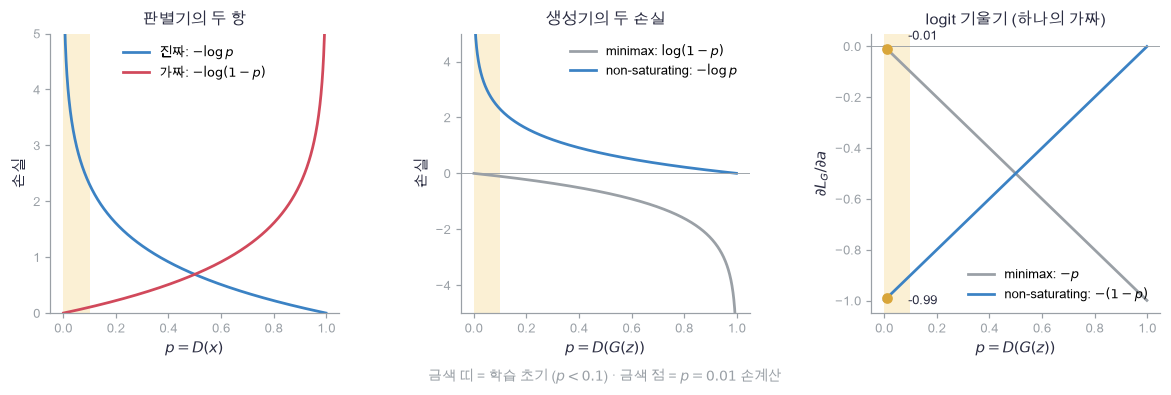

In [7]:
plot_generator_losses(loss_p, loss_real_term, loss_fake_term, loss_mm, loss_ns, grad_mm, grad_ns, hand_p)

🔍 **확인** · 왼쪽은 판별기의 두 항입니다. 진짜에는 $p$가 작을수록, 가짜에는 $p$가 클수록 벌이 커집니다.
가운데에서 생성기의 두 손실은 모두 오른쪽으로 갈수록(속일수록) 내려가지만, 금색 띠(학습 초기 $p<0.1$)에서 회색 minimax 곡선은 **거의 평평**합니다. 평평하면 기울기가 없습니다.
오른쪽에서 그 차이가 숫자로 보입니다. $p=0.01$에서 minimax의 기울기는 $-0.01$, non-saturating은 $-0.99$입니다. 학습이 진행돼 $p$가 커지면 반대로 non-saturating 쪽이 작아집니다.
아래 구현은 두 손실을 **값과 logit 기울기를 함께** 돌려줍니다. 2절부터 이 기울기가 backward의 출발점이 됩니다.

In [8]:
def sigmoid(a):
    """로지스틱 함수 σ(a) = 1/(1 + e^{−a}) (02번 7절). a: 아무 모양 → 같은 모양, 값은 0–1."""
    return 1.0 / (1.0 + np.exp(-a))

In [9]:
def discriminator_loss(logit_real, logit_fake):
    """판별기 손실 L_D = mean softplus(−a_real) + mean softplus(a_fake) 와 두 logit 기울기 (02번 7절).
    logit_real: (N, 1), logit_fake: (M, 1) → (손실: 숫자, d_real: (N, 1), d_fake: (M, 1))."""
    loss = np.logaddexp(0, -logit_real).mean() + np.logaddexp(0, logit_fake).mean()
    d_real = (sigmoid(logit_real) - 1) / logit_real.size             # (N, 1): (σ(a) − 1)/N
    d_fake = sigmoid(logit_fake) / logit_fake.size                   # (M, 1): σ(a)/M
    return loss, d_real, d_fake

In [10]:
def generator_loss(logit_fake, mode="non-saturating"):
    """생성기 손실과 logit 기울기. non-saturating 은 mean softplus(−a) 로 기울기 −(1 − p)/M,
    minimax 는 −mean softplus(a) 로 기울기 −p/M. logit_fake: (M, 1) → (손실: 숫자, d_logit: (M, 1))."""
    p = sigmoid(logit_fake)                                          # (M, 1): D(G(z))
    if mode == "non-saturating":
        return np.logaddexp(0, -logit_fake).mean(), (p - 1) / logit_fake.size
    return -np.logaddexp(0, logit_fake).mean(), -p / logit_fake.size

In [11]:
# 쓰는 것: hand_p (1절 계산 셀)
hand_logit = np.array([[np.log(hand_p / (1 - hand_p))]])             # (1, 1): σ(a) = 0.01 이 되는 logit
np.testing.assert_allclose(sigmoid(hand_logit), hand_p)              # 검산: σ(a) = p = 0.01
hand_mm_loss, hand_mm_grad = generator_loss(hand_logit, "minimax")
hand_ns_loss, hand_ns_grad = generator_loss(hand_logit)
np.testing.assert_allclose(hand_mm_grad, -hand_p)                    # 검산: minimax 기울기 = −p = −0.01
np.testing.assert_allclose(hand_ns_grad, -(1 - hand_p))              # 검산: non-saturating 기울기 = −(1 − p) = −0.99


def mm_scalar():
    """검사용: hand_logit 의 함수로 본 minimax 생성기 손실."""
    return float(generator_loss(hand_logit, "minimax")[0])


def ns_scalar():
    """검사용: hand_logit 의 함수로 본 non-saturating 생성기 손실."""
    return float(generator_loss(hand_logit)[0])


mm_error = rel_error(hand_mm_grad, numerical_gradient(mm_scalar, hand_logit))
ns_error = rel_error(hand_ns_grad, numerical_gradient(ns_scalar, hand_logit))
assert max(mm_error, ns_error) < 1e-6, "두 생성기 손실의 logit 기울기가 중심차분과 1e−6 안에서 같아야 합니다"
print(f"손실 minimax {hand_mm_loss:.4f} · non-saturating {hand_ns_loss:.4f}"
      f" · 기울기 손계산 −{hand_p} 와 −{1 - hand_p} 확인"
      f" · 중심차분 상대오차 minimax {mm_error:.2e} · non-saturating {ns_error:.2e}")

손실 minimax -0.0101 · non-saturating 4.6052 · 기울기 손계산 −0.01 와 −0.99 확인 · 중심차분 상대오차 minimax 8.08e-11 · non-saturating 2.03e-10


In [12]:
easy_loss, _, _ = discriminator_loss(np.array([[6.0]]), np.array([[-6.0]]))    # 진짜에 높은 점수, 가짜에 낮은 점수
hard_loss, _, _ = discriminator_loss(np.array([[-6.0]]), np.array([[6.0]]))    # 정반대로 틀린 경우
even_loss, even_real, even_fake = discriminator_loss(np.zeros((4, 1)), np.zeros((4, 1)))   # 모두 D(x) = 1/2
assert easy_loss < 0.01, "잘 가르는 판별기의 손실은 0 에 가까워야 합니다"
assert hard_loss > 10, "정반대로 틀린 판별기의 손실은 커야 합니다"
np.testing.assert_allclose(even_loss, 2 * np.log(2))                 # 검산: D = 1/2 이면 −log(1/2) 두 개 = 2 log 2
np.testing.assert_allclose(even_real, -0.125)                        # 검산: (σ(0) − 1)/4 = (0.5 − 1)/4
np.testing.assert_allclose(even_fake, 0.125)                         # 검산: σ(0)/4 = 0.5/4
print(f"쉬운 경우 {easy_loss:.4f} · 틀린 경우 {hard_loss:.4f} · 반반 {even_loss:.4f} (2 log 2 = {2 * np.log(2):.4f})")

쉬운 경우 0.0050 · 틀린 경우 12.0050 · 반반 1.3863 (2 log 2 = 1.3863)


🔍 **확인** · 손계산 두 값 $-0.01$과 $-0.99$가 그대로 나오고, 중심차분과의 상대오차가 $10^{-6}$ 아래입니다.
판별기 쪽에서는 잘 가르면 손실이 0에 가깝고, 정반대로 틀리면 12 근처로 커지며, 진짜와 가짜를 똑같이 1/2로 보면 정확히 $2\log2=1.3863$입니다. 이 $2\log2$는 3절에서 **균형점**의 값으로 다시 나옵니다.

### ✏️ 연습 1 · non-saturating 손실의 logit 기울기

연습은 코딩 테스트처럼 **함수 뼈대가 미리 있고 핵심 한두 줄만 비어 있습니다.** `raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓴 뒤, 셀을 실행하고 바로 아래 검사 셀을 실행하세요. 아직 채우지 않았으면 안내문만 나오고, 값이 다르면 "손계산과 다릅니다"가 나옵니다. 막히면 그 아래 "정답 보기"를 펼칩니다.

가짜 표본의 logit `logit_fake` `(M, 1)`에서 non-saturating 생성기 손실의 기울기 $\partial L_G^{ns}/\partial a=(\sigma(a)-1)/M$ 한 줄을 채우세요. 검사는 $p=0.01,0.5,0.9$의 손계산 값과 중심차분 두 가지로 합니다.

In [13]:
def exercise_ns_gradient(logit_fake):
    """연습 1: non-saturating 생성기 손실의 logit 기울기. logit_fake: (M, 1) → d_logit: (M, 1)."""
    assert logit_fake.ndim == 2, "logit 은 (M, 1) 모양이어야 합니다"
    ### 이 주석 아래에 다음을 구현하세요.
    ### 구현할 내용: d_logit = (σ(a) − 1) / M   (모양 (M, 1), M 은 logit_fake 의 원소 수)
    ### 힌트: 1절 generator_loss 가 non-saturating 에서 돌려주는 둘째 값 한 줄입니다. σ 는 위에서 정의한 sigmoid.
    raise NotImplementedError
    return d_logit

In [14]:
def check_ns_gradient(candidate):
    """p = 0.01, 0.5, 0.9 의 손계산 값과 중심차분으로 검사합니다. 통과하면 메시지를 출력합니다."""
    example_p = np.array([[0.01], [0.5], [0.9]])                     # (3, 1): 학습 초기·중간·후기
    example_logit = np.log(example_p / (1 - example_p))              # (3, 1): 그 확률이 나오는 logit
    actual = candidate(example_logit)
    assert np.shape(actual) == (3, 1), f"기울기는 logit 과 같은 (3, 1) 이어야 하는데 {np.shape(actual)} 입니다"
    np.testing.assert_allclose(actual, -(1 - example_p) / 3)         # 검산: 손계산 −(1 − p)/M, M = 3

    def example_scalar():
        """검사기용: 세 logit 의 non-saturating 손실 (표본 평균)."""
        return float(np.logaddexp(0, -example_logit).mean())

    np.testing.assert_allclose(actual, numerical_gradient(example_scalar, example_logit), atol=1e-8)   # 검산: 중심차분
    print("non-saturating 기울기: 손계산·중심차분과 일치합니다.")


run_check(check_ns_gradient, exercise_ns_gradient, hint="d_logit = (sigmoid(logit_fake) - 1) / logit_fake.size")

☐ exercise_ns_gradient: 아직 채우지 않았습니다. `raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓰세요.
   힌트: d_logit = (sigmoid(logit_fake) - 1) / logit_fake.size


📎 **정답** · 막히면 펼쳐 보고, 다시 접고 스스로 써 보세요.

<details>
<summary>정답 보기</summary>

```python
d_logit = (sigmoid(logit_fake) - 1) / logit_fake.size
```

</details>

## 🔑 2. 기울기가 판별기를 지나 생성기로 옵니다

**이 절에서 가져갈 것:** 생성기의 기울기는 판별기의 backward가 돌려주는 **입력 기울기** $dX_{fake}$에서 출발합니다. 그 값을 생성기 출력의 상류 기울기로 그대로 넘겨 생성기의 backward를 한 번 더 부르면 $d\theta_G$가 나오고, 같이 계산된 $d\theta_D$는 **버립니다**. 반대로 판별기를 갱신할 때는 가짜 표본을 상수로 보고 $dX_{fake}$를 버립니다.

두 모델이 한 줄로 이어져 있습니다. $z\to G\to\hat X\to D\to a\to L$. 손실은 하나지만 **누구를 갱신하느냐**에 따라 쓰는 기울기가 다릅니다.
생성기를 갱신할 때는 판별기를 "고정된 채점 기계"로 보고 그 안을 통과시켜 기울기를 끌고 오고, 판별기를 갱신할 때는 가짜 표본을 "이미 만들어진 데이터"로 봅니다.

> **용어**
>
> - **입력 기울기(input gradient)** $dX=\partial L/\partial X$: backward가 파라미터 기울기와 함께 돌려주는, **입력에 대한** 기울기 (03번 5절). 층을 쌓을 때 아래 층으로 내려보내는 값이고, GAN에서는 이것이 두 모델을 잇는 다리입니다.
> - **stop-gradient**: 어떤 값을 상수로 취급해 그 너머로 기울기를 보내지 않는 것 (13번 5절). 여기서는 판별기를 갱신할 때 $\hat X$가 상수입니다. 코드에서는 "받은 기울기를 쓰지 않는다"가 곧 stop-gradient입니다.
> - **파라미터 사전(parameter dict)**: 층 하나를 `{"W": (a, b), "b": (b,)}` 사전으로 두고 층을 목록으로 쌓은 것. 기울기도 같은 모양의 사전이라 `p[key] -= lr * grad[key]`처럼 짝지어 갱신합니다 (05번 5절과 같은 관례).

연쇄법칙을 두 토막으로 끊어 씁니다. 배치 크기 $M$, 잠재 차원 $d_z$, 데이터 차원 $D$일 때 $z\in\mathbb R^{M\times d_z}$, $\hat X\in\mathbb R^{M\times D}$, $a\in\mathbb R^{M\times1}$입니다.

$$dX_{fake}=\frac{\partial L_G}{\partial\hat X}=\Big(\text{D의 backward}\Big)\!\left(\frac{\partial L_G}{\partial a}\right)\in\mathbb R^{M\times D},
\qquad \frac{\partial L_G}{\partial\theta_G}=\Big(\text{G의 backward}\Big)\big(dX_{fake}\big).$$

첫 줄에서 판별기의 backward는 $d\theta_D$와 $dX_{fake}$를 **둘 다** 계산하지만 생성기 갱신에서는 $dX_{fake}$만 받아 씁니다. 둘째 줄에서 생성기의 backward는 $dX_{fake}$를 상류 기울기로 받아 $d\theta_G$를 냅니다.
판별기 갱신은 같은 backward를 진짜·가짜 두 갈래에 각각 부르고, 두 갈래의 **파라미터 기울기를 더한** 뒤 $dX$는 버립니다.

$$\frac{\partial L_D}{\partial\theta_D}=\Big(\text{D의 backward}\Big)\!\left(\frac{\partial L_D}{\partial a^{real}}\right)+\Big(\text{D의 backward}\Big)\!\left(\frac{\partial L_D}{\partial a^{fake}}\right).$$

아래 셀은 아직 함수를 만들지 않고, 작은 두 층짜리 $G$와 $D$를 NumPy로 직접 써서 모양이 어떻게 이어지는지만 확인합니다.

> **코드**
>
> - `x_fake, _ = mlp_forward(z, g_params)`: 두 개를 돌려주는 함수에서 첫 번째만 쓰고 두 번째는 `_`에 버립니다. `_`는 "이 값은 쓰지 않는다"는 뜻의 이름입니다.
> - `A @ W + b`: `(N, a) @ (a, b)` 뒤에 `(b,)`를 브로드캐스팅으로 모든 행에 더합니다 (00번 4절).
> - `zip(sizes[:-1], sizes[1:])`: 층 크기 목록을 이웃한 두 개씩 짝지어 `(입력, 출력)` 쌍으로 만듭니다. `[2, 64, 1]` 이면 `(2, 64)` 와 `(64, 1)` 두 쌍입니다.

In [15]:
# 쓰는 것: sigmoid (1절)
paths_rng = np.random.default_rng(28)
paths_batch, paths_z_dim, paths_x_dim = 8, 16, 32                    # 배치 8, 잠재 16차원, 데이터 32차원 (5절 MNIST 좌표와 같은 크기)
paths_z = paths_rng.normal(size=(paths_batch, paths_z_dim))          # (8, 16): 잠재 벡터
paths_g1 = paths_rng.normal(size=(paths_z_dim, 64)) * 0.1            # (16, 64): G 의 첫 층 가중치
paths_g2 = paths_rng.normal(size=(64, paths_x_dim)) * 0.1            # (64, 32): G 의 둘째 층 가중치
paths_x_fake = np.tanh(paths_z @ paths_g1) @ paths_g2                # (8, 32): 가짜 표본 x̂ = G(z)
paths_d1 = paths_rng.normal(size=(paths_x_dim, 64)) * 0.1            # (32, 64): D 의 첫 층 가중치
paths_d2 = paths_rng.normal(size=(64, 1)) * 0.1                      # (64, 1): D 의 둘째 층 가중치
paths_logit = np.tanh(paths_x_fake @ paths_d1) @ paths_d2            # (8, 1): 판별기 점수 a = D(x̂)
paths_d_logit = (sigmoid(paths_logit) - 1) / paths_logit.size        # (8, 1): ∂L_G^ns/∂a — 뒤로 가는 출발점
paths_blocks = [("$z$", f"({paths_batch}, {paths_z_dim})"), ("$G_{\\theta_G}$", "은닉 64"),
                ("$\\hat X$", f"({paths_batch}, {paths_x_dim})"), ("$D_{\\theta_D}$", "은닉 64"),
                ("$a$", f"({paths_batch}, 1)"), ("$L_G$", "숫자 하나")]
print("z", paths_z.shape, "→ x̂", paths_x_fake.shape, "→ a", paths_logit.shape,
      "· 뒤로 출발하는 ∂L_G/∂a", paths_d_logit.shape, "· dX_fake 는", paths_x_fake.shape, "여야 합니다")

z (8, 16) → x̂ (8, 32) → a (8, 1) · 뒤로 출발하는 ∂L_G/∂a (8, 1) · dX_fake 는 (8, 32) 여야 합니다


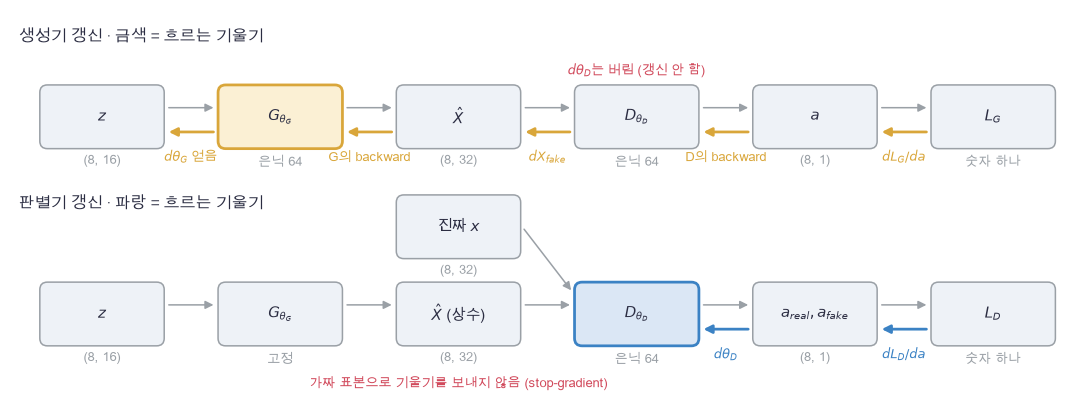

In [16]:
plot_gan_paths(paths_blocks, f"({paths_batch}, {paths_x_dim})")

🔍 **확인** · 위 줄이 **생성기 갱신**입니다. 손실에서 출발한 금색 화살표가 $D$를 거슬러 $\hat X$까지 와서 $dX_{fake}$가 되고, 거기서 $G$의 backward로 이어져 $d\theta_G$가 됩니다. $D$ 상자 위에 빨간 글씨로 적힌 대로 이때 계산된 $d\theta_D$는 버립니다.
아래 줄이 **판별기 갱신**입니다. 진짜 $x$와 가짜 $\hat X$ 두 갈래가 $D$로 들어가고, 파란 화살표는 $D$에서 멈춥니다. $\hat X$ 아래 빨간 글씨가 stop-gradient이고, 그래서 $G$는 이 갱신에서 조금도 움직이지 않습니다.
$dX_{fake}$의 모양이 $\hat X$와 같은 `(8, 32)`라는 점이 중요합니다. 모양이 같아야 다음 backward의 상류 기울기로 그대로 넘길 수 있습니다.
아래부터 이 도식을 함수로 옮깁니다. 03번의 MLP와 04번의 Adam을 이 노트북 안에 짧게 다시 정의합니다.

In [17]:
def activation_forward(Z, activation):
    """은닉층 활성화 (03번 3절): tanh 또는 ReLU. Z: (N, H) → (N, H)."""
    if activation == "tanh":
        return np.tanh(Z)
    return np.maximum(Z, 0)


def activation_backward(Z, activation):
    """활성화의 도함수 (03번 3절): tanh 는 1 − tanh(Z)², ReLU 는 Z > 0. Z: (N, H) → (N, H)."""
    if activation == "tanh":
        return 1 - np.tanh(Z) ** 2
    return (Z > 0).astype(float)

In [18]:
def init_mlp(sizes, rng):
    """층 크기 목록으로 MLP 파라미터 사전 목록을 만듭니다 (03번 4절, 표준편차 √(2/(입력+출력))).
    sizes: [입력, 은닉, …, 출력], rng: 난수 생성기 → [{"W": (a, b), "b": (b,)}, …]."""
    return [{"W": rng.normal(size=(a, b)) * np.sqrt(2 / (a + b)), "b": np.zeros(b)}
            for a, b in zip(sizes[:-1], sizes[1:])]

In [19]:
def mlp_forward(X, params, activation="tanh"):
    """MLP forward (03번 4절). 마지막 층은 활성화 없이 그대로 냅니다(판별기는 logit, 생성기는 좌표).
    X: (N, D_in), params: 층 사전 목록 → (출력: (N, D_out), caches: 층마다 (입력 A, 선형 출력 Z))."""
    A = X
    caches = []
    for i, layer in enumerate(params):
        Z = A @ layer["W"] + layer["b"]                              # (N, 폭): 선형층
        caches.append((A, Z))
        A = Z if i == len(params) - 1 else activation_forward(Z, activation)
    return A, caches

In [20]:
def mlp_backward(dout, params, caches, activation="tanh"):
    """MLP backward (03번 5절). 파라미터 기울기와 **입력 기울기** dX 를 함께 돌려줍니다.
    dout: (N, D_out) 상류 기울기, caches: mlp_forward 의 것 → (dX: (N, D_in), grads: params 와 같은 모양의 사전 목록)."""
    grads = [None] * len(params)
    dZ = dout
    for i in range(len(params) - 1, -1, -1):                         # 마지막 층부터 거꾸로
        A_prev, Z = caches[i]
        grads[i] = {"W": A_prev.T @ dZ, "b": dZ.sum(axis=0)}         # (in, out), (out,): affine backward 두 식
        dA = dZ @ params[i]["W"].T                                   # (N, in): 한 층 아래로 내린 기울기
        if i > 0:
            dZ = dA * activation_backward(caches[i - 1][1], activation)   # 아래 층 활성화의 도함수를 곱함
    return dA, grads

In [21]:
def adam_init(params):
    """Adam 상태 (m, v) 를 파라미터마다 0 으로 (04번 6절). params → 같은 키의 사전 목록."""
    return [{key: (np.zeros_like(value), np.zeros_like(value)) for key, value in layer.items()} for layer in params]


def adam_step(params, grads, state, step, lr, beta1=0.5):
    """Adam 갱신 (04번 6절). GAN 관례로 β₁ 만 0.9 → 0.5 로 낮춥니다. params 와 state 를 제자리에서 바꿉니다.
    step: 1 부터 세는 갱신 횟수(편향 보정에 씀), lr: 학습률."""
    for layer, grad, moments in zip(params, grads, state):
        for key in layer:
            m, v = moments[key]
            m = beta1 * m + (1 - beta1) * grad[key]                  # 1차 모멘트
            v = 0.999 * v + 0.001 * grad[key] ** 2                   # 2차 모멘트
            layer[key] -= lr * (m / (1 - beta1 ** step)) / (np.sqrt(v / (1 - 0.999 ** step)) + 1e-8)
            moments[key] = (m, v)

In [22]:
def discriminator_step(x_real, z, g_params, d_params, d_state, step, lr, activation="tanh"):
    """판별기 한 번 갱신. 가짜를 G 로 만들되 **상수로 보고**(13번 5절 stop-gradient) D 의 파라미터 기울기만 씁니다.
    x_real: (N, D), z: (M, d_z) → 손실 숫자 하나. d_params 와 d_state 만 제자리에서 바뀝니다."""
    # 쓰는 것: discriminator_loss (1절) · mlp_forward, mlp_backward, adam_step (2절)
    x_fake, _ = mlp_forward(z, g_params, activation)                 # (M, D): 가짜 표본. 여기서 끊습니다
    logit_real, cache_real = mlp_forward(x_real, d_params, activation)   # (N, 1)
    logit_fake, cache_fake = mlp_forward(x_fake, d_params, activation)   # (M, 1)
    loss, d_real, d_fake = discriminator_loss(logit_real, logit_fake)
    _, grads_real = mlp_backward(d_real, d_params, cache_real, activation)   # 진짜 갈래. dX 는 쓰지 않음
    _, grads_fake = mlp_backward(d_fake, d_params, cache_fake, activation)   # 가짜 갈래. dX_fake 도 쓰지 않음
    grads = [{key: grads_real[i][key] + grads_fake[i][key] for key in grads_real[i]}
             for i in range(len(d_params))]                          # 두 갈래의 파라미터 기울기를 더함
    adam_step(d_params, grads, d_state, step, lr)
    return loss

In [23]:
def generator_step(z, g_params, d_params, g_state, step, lr, activation="tanh", mode="non-saturating"):
    """생성기 한 번 갱신. D 의 backward 가 돌려준 dX_fake 를 G 출력의 상류 기울기로 넘기고, D 의 파라미터 기울기는 버립니다.
    z: (M, d_z) → 손실 숫자 하나. g_params 와 g_state 만 제자리에서 바뀝니다."""
    # 쓰는 것: generator_loss (1절) · mlp_forward, mlp_backward, adam_step (2절)
    x_fake, cache_g = mlp_forward(z, g_params, activation)           # (M, D)
    logit_fake, cache_d = mlp_forward(x_fake, d_params, activation)  # (M, 1)
    loss, d_logit = generator_loss(logit_fake, mode)                 # (M, 1): ∂L_G/∂a
    dx_fake, _ = mlp_backward(d_logit, d_params, cache_d, activation)    # (M, D): D 를 지나온 입력 기울기. dθ_D 는 버림
    _, grads = mlp_backward(dx_fake, g_params, cache_g, activation)      # G 의 파라미터 기울기
    adam_step(g_params, grads, g_state, step, lr)
    return loss

In [24]:
# 쓰는 것: init_mlp, mlp_forward, mlp_backward (2절) · generator_loss (1절)
check_rng = np.random.default_rng(280)
check_g = init_mlp([2, 6, 1], check_rng)                             # 작은 G: 잠재 2 → 은닉 6 → 표본 1
check_d = init_mlp([1, 5, 1], check_rng)                             # 작은 D: 표본 1 → 은닉 5 → logit 1
check_z = check_rng.normal(size=(4, 2))                              # (4, 2): 잠재 4개
check_x_fake, check_cache_g = mlp_forward(check_z, check_g)
check_logit, check_cache_d = mlp_forward(check_x_fake, check_d)
_, check_d_logit = generator_loss(check_logit)                       # (4, 1): ∂L_G/∂a
check_dx_fake, _ = mlp_backward(check_d_logit, check_d, check_cache_d)   # (4, 1): dX_fake
_, check_g_grads = mlp_backward(check_dx_fake, check_g, check_cache_g)   # G 파라미터 기울기
assert check_dx_fake.shape == check_x_fake.shape, "dX_fake 는 x̂ 와 같은 모양이어야 합니다"


def generator_scalar():
    """검사용: D 를 고정한 채 G 파라미터만의 함수로 본 생성기 손실 L_G."""
    return float(generator_loss(mlp_forward(mlp_forward(check_z, check_g)[0], check_d)[0])[0])

In [25]:
# 쓰는 것: check_g, check_g_grads, generator_scalar (2절 검산 셀)
g_errors = {}
for layer_index, layer in enumerate(check_g):
    for key, value in layer.items():
        numeric = numerical_gradient(generator_scalar, value)        # D 를 고정하고 G 의 이 배열만 흔들어 잰 중심차분
        g_errors[f"층{layer_index}·{key}"] = rel_error(check_g_grads[layer_index][key], numeric)
assert max(g_errors.values()) < 1e-6, "G 파라미터 기울기의 상대오차가 1e−6 아래여야 합니다"
print("판별기를 지나온 G 파라미터 기울기의 최대 상대오차:", f"{max(g_errors.values()):.2e}", "·", {k: f"{v:.1e}" for k, v in g_errors.items()})

판별기를 지나온 G 파라미터 기울기의 최대 상대오차: 1.45e-09 · {'층0·W': '5.3e-10', '층0·b': '2.9e-10', '층1·W': '1.5e-09', '층1·b': '9.4e-11'}


In [26]:
def same_params(left, right):
    """두 파라미터 사전 목록의 모든 배열이 완전히 같은지. (목록, 목록) → True/False."""
    return all(np.array_equal(a[key], b[key]) for a, b in zip(left, right) for key in a)


def copy_params(params):
    """파라미터 사전 목록을 값까지 복사합니다. params → 같은 모양의 새 목록."""
    return [{key: value.copy() for key, value in layer.items()} for layer in params]

In [27]:
# 쓰는 것: check_g, check_d, check_z, check_rng (2절 검산 셀) · discriminator_step, generator_step, adam_init (2절) · mix_sample (📎 혼합 셀)
before_g = copy_params(check_g)                                      # 1. 판별기 한 스텝: G 는 그대로여야 함
before_d = copy_params(check_d)
discriminator_step(mix_sample(4, check_rng)[:, None], check_z, check_g, check_d, adam_init(check_d), 1, 1e-3)
assert same_params(before_g, check_g), "판별기 갱신은 생성기 파라미터를 바꾸지 않아야 합니다 (dX_fake 를 쓰지 않음)"
assert not same_params(before_d, check_d), "판별기 갱신은 판별기 파라미터를 바꿔야 합니다"
after_d = copy_params(check_d)                                       # 2. 생성기 한 스텝: D 는 그대로여야 함
generator_step(check_z, check_g, check_d, adam_init(check_g), 1, 1e-3)
assert same_params(after_d, check_d), "생성기 갱신은 판별기 파라미터를 바꾸지 않아야 합니다 (dθ_D 를 버림)"
assert not same_params(before_g, check_g), "생성기 갱신은 생성기 파라미터를 바꿔야 합니다"
print("stop-gradient 검산 통과: 판별기 스텝은 G 를, 생성기 스텝은 D 를 건드리지 않습니다.")

stop-gradient 검산 통과: 판별기 스텝은 G 를, 생성기 스텝은 D 를 건드리지 않습니다.


🔍 **확인** · 첫 줄이 이 노트북에서 가장 중요한 숫자입니다. 판별기를 고정한 채 생성기 파라미터를 하나씩 흔들어 잰 중심차분과, 판별기의 backward를 지나온 해석적 기울기의 상대오차가 $10^{-6}$ 아래입니다.
즉 `mlp_backward`를 두 번 부른 두 줄이 연쇄법칙 전체를 정확히 계산합니다.
둘째 검산은 "무엇을 버리는가"를 확인합니다. 판별기 스텝 뒤에도 $G$의 배열은 **한 비트도** 바뀌지 않고, 생성기 스텝 뒤에도 $D$는 그대로입니다. 두 모델이 서로의 갱신에 끌려가지 않아야 교대 갱신이 의미를 가집니다.

### ✏️ 연습 2 · dX_fake를 생성기의 상류 기울기로 넘기기

판별기를 지나온 `dx_fake` `(M, D)`와 생성기의 파라미터·캐시를 받아 **생성기 파라미터 기울기**를 얻는 한 줄을 채우세요. `mlp_backward`는 `(dX, grads)` 두 개를 돌려주는데 여기서는 `grads`만 필요합니다. 검사는 검사기 안에서 만든 작은 $G$·$D$에서 중심차분과 대조합니다.

In [28]:
def exercise_generator_grads(dx_fake, g_params, cache_g):
    """연습 2: D 를 지나온 dX_fake 를 상류 기울기로 넘겨 G 파라미터 기울기를 얻습니다.
    dx_fake: (M, D), g_params: 층 사전 목록, cache_g: mlp_forward 의 캐시 → grads: g_params 와 같은 모양의 사전 목록."""
    assert len(cache_g) == len(g_params), "캐시 수와 층 수가 같아야 합니다"
    ### 이 주석 아래에 다음을 구현하세요.
    ### 구현할 내용: G 의 backward 를 dx_fake 로 한 번 불러 파라미터 기울기 grads 만 받기
    ### 힌트: 2절 generator_step 의 끝에서 두 번째 줄입니다. 돌려주는 두 값 중 dX 는 _ 로 버립니다.
    raise NotImplementedError
    return grads

In [29]:
def check_generator_grads(candidate):
    """검사기 안에서 만든 작은 G·D 에서 중심차분과 대조합니다. 통과하면 메시지를 출력합니다."""
    # 쓰는 것: generator_loss (1절) · init_mlp, mlp_forward, mlp_backward (2절)
    rng_check = np.random.default_rng(2801)
    g_check = init_mlp([2, 5, 1], rng_check)
    d_check = init_mlp([1, 4, 1], rng_check)
    z_check = rng_check.normal(size=(3, 2))
    x_check, cache_g_check = mlp_forward(z_check, g_check)
    logit_check, cache_d_check = mlp_forward(x_check, d_check)
    dx_check, _ = mlp_backward(generator_loss(logit_check)[1], d_check, cache_d_check)
    grads = candidate(dx_check, g_check, cache_g_check)
    assert len(grads) == len(g_check), f"층 수만큼 {len(g_check)} 개의 기울기 사전이어야 하는데 {len(grads)} 개입니다"

    def check_scalar():
        """검사기용: D 를 고정한 채 G 파라미터만의 함수로 본 L_G."""
        return float(generator_loss(mlp_forward(mlp_forward(z_check, g_check)[0], d_check)[0])[0])

    for index, layer in enumerate(g_check):
        for key, value in layer.items():
            numeric = numerical_gradient(check_scalar, value)
            assert rel_error(grads[index][key], numeric) < 1e-6, f"층 {index} 의 {key} 기울기가 중심차분과 다릅니다"
    print("생성기 기울기: 중심차분과 1e−6 안에서 일치합니다.")


run_check(check_generator_grads, exercise_generator_grads, hint="_, grads = mlp_backward(dx_fake, g_params, cache_g)")

☐ exercise_generator_grads: 아직 채우지 않았습니다. `raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓰세요.
   힌트: _, grads = mlp_backward(dx_fake, g_params, cache_g)


📎 **정답** · 막히면 펼쳐 보고, 다시 접고 스스로 써 보세요.

<details>
<summary>정답 보기</summary>

```python
_, grads = mlp_backward(dx_fake, g_params, cache_g)
```

</details>

## 🔑 3. 교대 갱신과 최적 판별기: 생성기를 고정하면 정답이 보입니다

**이 절에서 가져갈 것:** 한 번의 바깥 반복마다 판별기를 $k_D$번, 생성기를 1번 번갈아 갱신하고 두 손실을 함께 기록합니다. 생성기를 고정하면 판별기의 최적해는 두 밀도의 비율로 정해진 $D^*(x)=p_{data}(x)/(p_{data}(x)+p_g(x))$이고, 그때 판별기 손실은 $2\log2-2\,\mathrm{JSD}(p_{data}\,\|\,p_g)$입니다. 두 분포가 같아지면 $D^*=1/2$, $L_D=2\log2$, $L_G=\log2$가 균형점입니다.

두 모델이 동시에 움직이면 "잘 되고 있는지"를 손실만 보고 말하기 어렵습니다. 판별기 손실이 내려가면 생성기가 밀리는 것이고 올라가면 판별기가 밀리는 것이라, **한쪽 숫자만으로는 좋고 나쁨을 정할 수 없습니다**.
그래서 먼저 한쪽을 세워 둡니다. 생성기를 아주 단순한 것으로 **고정**하면 $p_g$를 닫힌식으로 쓸 수 있고, 판별기의 정답도 닫힌식으로 나옵니다. 학습한 판별기를 그 정답과 겹쳐 보면 "제대로 학습되고 있는가"를 처음으로 눈으로 확인할 수 있습니다.

> **용어**
>
> - **최적 판별기** $D^*$: 생성기를 고정했을 때 $L_D$를 가장 작게 만드는 함수. 자리마다 따로 최소화되므로 신경망과 무관하게 닫힌식으로 나옵니다.
> - **JSD(Jensen-Shannon divergence)**: 두 분포의 다름을 재는 값 $\mathrm{JSD}(p\,\|\,q)=\frac{1}{2}\mathrm{KL}(p\,\|\,m)+\frac{1}{2}\mathrm{KL}(q\,\|\,m)$, $m=\frac{1}{2}(p+q)$ (12번 3절의 KL). 항상 0 이상이고, 두 분포가 같을 때만 0입니다.
> - **교대 갱신(alternating update)**: 두 모델을 동시에 풀지 않고 번갈아 한쪽씩 갱신하는 방법. 판별기를 $k_D$번, 생성기를 1번이 관례입니다.
> - **균형점(equilibrium)**: 두 목적이 서로를 밀어 더 나아갈 데가 없는 상태. GAN에서는 $p_g=p_{data}$이고 판별기가 구분을 포기한 자리입니다.

자리 $x$ 하나만 떼어 보면 판별기 손실의 적분 안쪽은 $-p_{data}(x)\log D(x)-p_g(x)\log(1-D(x))$입니다. $D(x)=t$로 두고 $t$로 미분해 0으로 놓으면

$$-\frac{p_{data}}{t}+\frac{p_g}{1-t}=0\;\Longrightarrow\;
D^*(x)=\frac{p_{data}(x)}{p_{data}(x)+p_g(x)},\qquad
\text{logit}^*(x)=\log\frac{D^*}{1-D^*}=\log p_{data}(x)-\log p_g(x).$$

판별기가 배우는 것은 두 밀도의 **로그 비율**입니다. 이 값을 $L_D$에 넣고 정리하면

$$L_D(D^*)=2\log2-2\,\mathrm{JSD}(p_{data}\,\|\,p_g)\;\le\;2\log2,$$

등호는 $p_g=p_{data}$일 때뿐입니다. 아래에서는 생성기를 $\hat x=1.5z+0.5$인 **선형 생성기**로 고정합니다. $z\sim\mathcal N(0,1)$이므로 $p_g=\mathcal N(0.5,1.5^2)$가 닫힌식이고, $D^*$와 $L_D(D^*)$를 격자 적분으로 정확히 계산할 수 있습니다.

> **코드**
>
> - `np.trapezoid(y, x)`: 격자 위의 값 `y`를 사다리꼴 규칙으로 적분합니다. 격자를 촘촘히 하면 참값에 가까워집니다.
> - `np.logaddexp(0, t)`: $\log(1+e^t)$ = softplus. 큰 $t$에서도 넘치지 않습니다.

In [30]:
FIXED_G_W, FIXED_G_B = 1.5, 0.5                                      # 고정할 선형 생성기 x̂ = 1.5 z + 0.5


def fixed_g_logpdf(x):
    """고정한 선형 생성기의 로그 밀도. z ~ N(0, 1) 이면 x̂ = w z + b 는 N(b, w²) (12번 1절). x: (N,) → (N,)."""
    return -0.5 * (np.log(2 * np.pi * FIXED_G_W ** 2) + ((x - FIXED_G_B) / FIXED_G_W) ** 2)

In [31]:
# 쓰는 것: mix_logpdf (📎 혼합 셀) · sigmoid (1절)
opt_x = np.linspace(-10, 10, 4001)                                   # (4001,): 적분용 격자 (양끝 밀도는 사실상 0)
opt_p_data = np.exp(mix_logpdf(opt_x))                               # (4001,): 진짜 밀도 p_data
opt_p_g = np.exp(fixed_g_logpdf(opt_x))                              # (4001,): 고정한 G 의 밀도 p_g
opt_logit_star = mix_logpdf(opt_x) - fixed_g_logpdf(opt_x)           # (4001,): logit* = log p_data − log p_g
opt_d_star = sigmoid(opt_logit_star)                                 # (4001,): D*(x)
opt_view = np.abs(opt_x) <= 5                                        # (4001,): 그림에 쓸 구간 |x| ≤ 5
opt_hand = int(np.argmin(np.abs(opt_x - (-2.0))))                    # 손계산할 자리 x = −2 의 격자 번호
print(f"x = {opt_x[opt_hand]:.2f} 에서 p_data {opt_p_data[opt_hand]:.6f} · p_g {opt_p_g[opt_hand]:.6f}"
      f" · D* {opt_d_star[opt_hand]:.5f} · logit* {opt_logit_star[opt_hand]:.4f}")

x = -2.00 에서 p_data 0.239459 · p_g 0.066318 · D* 0.78312 · logit* 1.2839


In [32]:
# 쓰는 것: opt_x, opt_p_data, opt_p_g, opt_logit_star (3절 계산 셀) · mix_logpdf (📎 혼합 셀) · fixed_g_logpdf (3절)
opt_mid = 0.5 * (opt_p_data + opt_p_g)                               # (4001,): 평균 분포 m = (p_data + p_g)/2
opt_kl_data = np.trapezoid(opt_p_data * (mix_logpdf(opt_x) - np.log(opt_mid)), opt_x)        # KL(p_data ‖ m)
opt_kl_g = np.trapezoid(opt_p_g * (fixed_g_logpdf(opt_x) - np.log(opt_mid)), opt_x)          # KL(p_g ‖ m)
opt_jsd = 0.5 * opt_kl_data + 0.5 * opt_kl_g
opt_loss_star = np.trapezoid(opt_p_data * np.logaddexp(0, -opt_logit_star)
                             + opt_p_g * np.logaddexp(0, opt_logit_star), opt_x)             # D* 를 넣은 L_D
np.testing.assert_allclose(opt_loss_star, 2 * np.log(2) - 2 * opt_jsd, atol=1e-6)            # 검산: L_D(D*) = 2 log 2 − 2 JSD
assert opt_loss_star < 2 * np.log(2), "두 분포가 다르면 최적 손실이 2 log 2 보다 작아야 합니다"
print(f"JSD {opt_jsd:.6f} · L_D(D*) {opt_loss_star:.6f} = 2log2 − 2JSD {2 * np.log(2) - 2 * opt_jsd:.6f} (2log2 = {2 * np.log(2):.6f})")

JSD 0.117102 · L_D(D*) 1.152090 = 2log2 − 2JSD 1.152090 (2log2 = 1.386294)


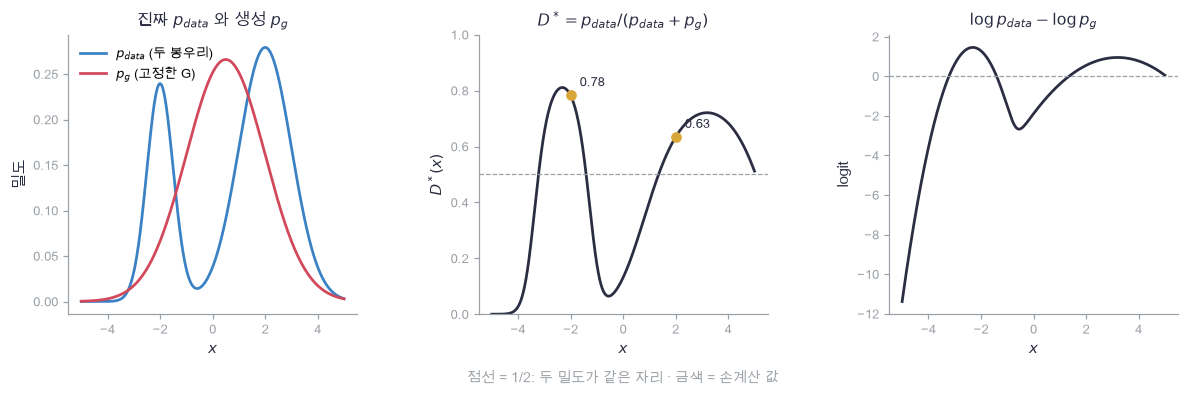

In [33]:
plot_optimal_discriminator(opt_x[opt_view], opt_p_data[opt_view], opt_p_g[opt_view],
                           opt_d_star[opt_view], opt_logit_star[opt_view], [-2.0, 2.0])

🔍 **확인** · 왼쪽에서 파란 $p_{data}$는 $-2$의 좁고 뾰족한 봉우리와 $2$의 넓은 봉우리 두 개, 빨간 $p_g$는 $0.5$를 중심으로 한 봉우리 하나입니다.
가운데 $D^*$는 두 밀도의 비율입니다. 진짜가 많은 $-2$ 근처에서는 0.78로 "진짜"라고 답하고, $p_g$만 있는 0 근처에서는 0.13으로 "가짜"라고 답합니다. 점선 1/2과 만나는 자리가 두 밀도가 같아지는 곳입니다.
오른쪽 logit은 $\log p_{data}-\log p_g$ 그 자체입니다. 왼쪽 끝에서는 $-11$ 까지 크게 음수가 됩니다. 진짜 밀도가 그쪽에서 훨씬 빨리 작아지기 때문이고, 오른쪽에서도 같은 이유로 결국 내려가지만 그림의 끝($x=5$)에서는 아직 0 근처($+0.05$)입니다.
$D^*$는 닫힌식일 뿐 신경망이 아닙니다. 아래에서 신경망 판별기를 **실제로 학습시켜** 이 곡선에 얼마나 다가가는지 봅니다.

In [34]:
def gan_train(sample_real, g_params, d_params, steps, batch, z_dim, rng,
              k_d=1, lr_d=2e-3, lr_g=2e-3, activation="tanh", snapshots=()):
    """교대 갱신 루프. 바깥 반복마다 D 를 k_d 번, G 를 1 번 갱신하고 두 손실을 기록합니다.
    sample_real(n, rng): 진짜 표본 (n, D) 를 돌려주는 함수, snapshots: 생성 샘플을 남길 바깥 반복 번호들
    → (history: {"d": [...], "g": [...]} 길이 steps, snaps: {번호: (4000, D)})."""
    # 쓰는 것: mlp_forward, adam_init, discriminator_step, generator_step (2절)
    d_state, g_state = adam_init(d_params), adam_init(g_params)
    history = {"d": [], "g": []}
    snaps = {}
    d_count = 0
    for t in range(steps):
        for _ in range(k_d):                                         # 1. 판별기를 k_d 번
            d_count += 1
            d_loss = discriminator_step(sample_real(batch, rng), rng.normal(size=(batch, z_dim)),
                                        g_params, d_params, d_state, d_count, lr_d, activation)
        g_loss = generator_step(rng.normal(size=(batch, z_dim)), g_params, d_params,   # 2. 생성기를 1 번
                                g_state, t + 1, lr_g, activation)
        history["d"].append(d_loss)
        history["g"].append(g_loss)
        if t in snapshots:                                           # 3. 같은 잠재 4,000개로 생성 샘플을 남김
            snaps[t] = mlp_forward(np.random.default_rng(99).normal(size=(4000, z_dim)), g_params, activation)[0]
    return history, snaps

In [35]:
# 쓰는 것: init_mlp, adam_init, discriminator_step (2절) · mix_sample (📎 혼합 셀) · FIXED_G_W, FIXED_G_B (3절)
fixed_g = [{"W": np.array([[FIXED_G_W]]), "b": np.array([FIXED_G_B])}]   # 층 하나짜리 선형 생성기 (활성화 없음)
only_rng = np.random.default_rng(281)
only_d = init_mlp([1, 64, 1], only_rng)                              # D: 표본 1 → 은닉 64 → logit 1
only_state = adam_init(only_d)
for step in range(1, 3001):                                          # G 는 고정이므로 판별기 스텝만 3,000번
    only_real = mix_sample(512, only_rng)[:, None]                   # (512, 1): 진짜 표본
    only_z = only_rng.normal(size=(512, 1))                          # (512, 1): 잠재
    only_loss = discriminator_step(only_real, only_z, fixed_g, only_d, only_state, step, 3e-3)
print(f"판별기만 3,000스텝 · 마지막 배치 손실 {only_loss:.4f} (닫힌식 최적 {opt_loss_star:.4f})")

판별기만 3,000스텝 · 마지막 배치 손실 1.1529 (닫힌식 최적 1.1521)


In [36]:
# 쓰는 것: only_d (3절 학습 셀) · opt_x, opt_p_data, opt_p_g, opt_d_star, opt_hand (3절 계산 셀) · opt_loss_star (3절 검산 셀) · mlp_forward (2절) · sigmoid (1절)
only_logit = mlp_forward(opt_x[:, None], only_d)[0][:, 0]            # (4001,): 학습한 판별기의 logit
only_curve = sigmoid(only_logit)                                     # (4001,): 학습한 D(x)
only_loss_int = np.trapezoid(opt_p_data * np.logaddexp(0, -only_logit)
                             + opt_p_g * np.logaddexp(0, only_logit), opt_x)   # 같은 격자 적분으로 잰 L_D
only_weight = (opt_p_data + opt_p_g) / (opt_p_data + opt_p_g).sum()  # (4001,): 밀도가 있는 자리에 무게를 두는 가중치
only_wrms = float(np.sqrt(np.sum(only_weight * (only_curve - opt_d_star) ** 2)))
assert only_loss_int >= opt_loss_star - 1e-9, "D* 가 최소이므로 학습한 판별기의 손실이 더 작을 수는 없습니다"
assert only_loss_int - opt_loss_star < 0.02, "학습한 판별기의 손실이 닫힌식 최적값과 0.02 안에 있어야 합니다"
assert only_wrms < 0.05, "밀도로 가중한 D − D* 의 RMS 가 0.05 아래여야 합니다"
assert abs(only_curve[opt_hand] - opt_d_star[opt_hand]) < 0.05, "x = −2 에서 손계산 D* 와 0.05 안에서 같아야 합니다"
print(f"L_D 적분 {only_loss_int:.6f} − 최적 {opt_loss_star:.6f} = {only_loss_int - opt_loss_star:.5f}"
      f" · 가중 RMS {only_wrms:.4f} · x = −2 에서 {only_curve[opt_hand]:.4f} vs D* {opt_d_star[opt_hand]:.4f}")

L_D 적분 1.155538 − 최적 1.152090 = 0.00345 · 가중 RMS 0.0266 · x = −2 에서 0.7739 vs D* 0.7831


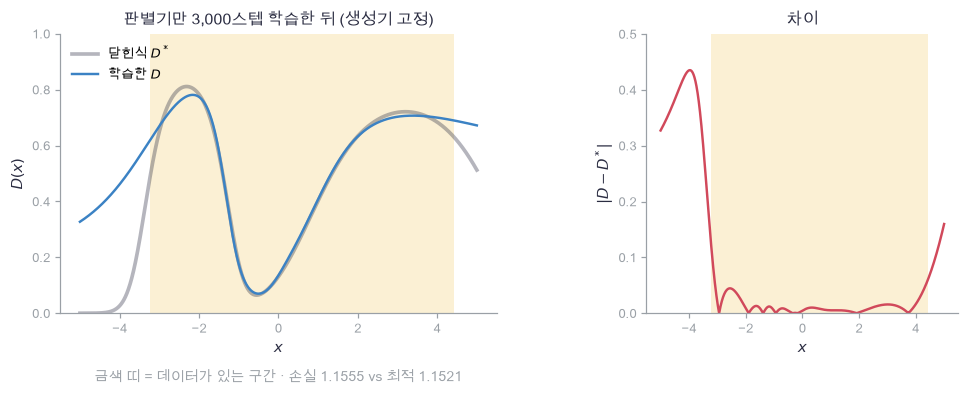

In [37]:
# 쓰는 것: opt_x, opt_p_data, opt_p_g, opt_d_star, opt_view (3절 계산 셀) · opt_loss_star (3절 검산 셀) · only_curve, only_loss_int (3절 검산 셀)
only_mass = opt_p_data + opt_p_g                                     # (4001,): 두 밀도의 합. 데이터가 있는 구간을 고르는 데 씀
only_region_x = opt_x[only_mass > 0.05 * only_mass.max()]            # 합이 최대의 5% 를 넘는 구간
only_region = (float(only_region_x[0]), float(only_region_x[-1]))
plot_discriminator_fit(opt_x[opt_view], only_curve[opt_view], opt_d_star[opt_view],
                       only_region, only_loss_int, opt_loss_star, 3000)

🔍 **확인** · 회색 굵은 선이 닫힌식 $D^*$, 파란 선이 학습한 판별기입니다. 금색 띠(두 밀도의 합이 최댓값의 5%를 넘는 구간) 안에서는 두 곡선이 거의 겹칩니다.
오른쪽 차이 그림에서 보이듯 어긋나는 곳은 띠 **바깥**입니다. 그 자리에는 표본이 거의 뽑히지 않으므로 판별기가 배울 근거가 없습니다. "데이터가 있는 곳에서만 맞는다"는 것은 32번 4절의 score 모델과 같은 현상입니다.
숫자로도 확인됩니다. 격자 적분으로 잰 판별기 손실이 닫힌식 최적값보다 0.003만큼 크고(최적보다 작을 수는 없습니다), 밀도로 가중한 $D-D^*$의 RMS는 0.027입니다.
이제 생성기도 함께 움직이게 합니다. 아래는 두 신경망을 교대로 2,000번 갱신하는 1차원 GAN입니다.

In [38]:
def sample_mix_real(n, rng):
    """1차원 혼합에서 진짜 표본 n 개를 (n, 1) 모양으로. gan_train 의 sample_real 자리에 넣습니다."""
    # 쓰는 것: mix_sample (📎 혼합 셀)
    return mix_sample(n, rng)[:, None]

In [39]:
# 쓰는 것: init_mlp, mlp_forward (2절) · gan_train (3절)
gan1d_rng = np.random.default_rng(282)
gan1d_g = init_mlp([2, 64, 1], gan1d_rng)                            # G: 잠재 2 → 은닉 64 → 표본 1
gan1d_d = init_mlp([1, 64, 1], gan1d_rng)                            # D: 표본 1 → 은닉 64 → logit 1
gan1d_snap_z = np.random.default_rng(99).normal(size=(4000, 2))      # (4000, 2): 스냅숏마다 같은 잠재를 씁니다
gan1d_before = mlp_forward(gan1d_snap_z, gan1d_g)[0][:, 0]           # (4000,): 학습 전 생성 샘플
gan1d_history, gan1d_snaps = gan_train(sample_mix_real, gan1d_g, gan1d_d, 2000, 256, 2, gan1d_rng,
                                       snapshots=(200, 1999))
print("학습 전 생성 샘플의 평균·표준편차", gan1d_before.mean().round(3), gan1d_before.std().round(3),
      "· 기록한 손실 개수", len(gan1d_history["d"]))

학습 전 생성 샘플의 평균·표준편차 -0.011 0.495 · 기록한 손실 개수 2000


In [40]:
# 쓰는 것: gan1d_snaps, gan1d_history (3절 학습 셀) · mix_responsibility (📎 혼합 셀) · MIX_PI, MIX_MU, MIX_SIGMA (📎 상수 셀)
gan1d_x = gan1d_snaps[1999][:, 0]                                    # (4000,): 학습이 끝난 뒤의 생성 샘플
gan1d_d_last = float(np.mean(gan1d_history["d"][-200:]))
gan1d_g_last = float(np.mean(gan1d_history["g"][-200:]))
true_mean = float(MIX_PI @ MIX_MU)                                   # Σ π_k μ_k = 0.8
true_std = float(np.sqrt(MIX_PI @ (MIX_SIGMA ** 2 + MIX_MU ** 2) - true_mean ** 2))   # √(Σ π_k(σ_k² + μ_k²) − 평균²)
gan1d_fraction = np.bincount(mix_responsibility(gan1d_x).argmax(axis=1), minlength=2) / len(gan1d_x)
assert abs(gan1d_d_last - 2 * np.log(2)) < 0.05, "판별기 손실이 균형값 2 log 2 근처여야 합니다"
assert abs(gan1d_g_last - np.log(2)) < 0.05, "생성기 손실이 균형값 log 2 근처여야 합니다"
assert abs(gan1d_x.mean() - true_mean) < 0.2, "생성 샘플의 평균이 닫힌식 0.8 과 0.2 안에서 같아야 합니다"
assert abs(gan1d_x.std() - true_std) < 0.2, "생성 샘플의 표준편차가 닫힌식과 0.2 안에서 같아야 합니다"
np.testing.assert_allclose(gan1d_fraction, MIX_PI, atol=0.05)        # 검산: 봉우리별 비율 ≈ π = (0.3, 0.7)
print(f"L_D {gan1d_d_last:.4f} (2log2 {2 * np.log(2):.4f}) · L_G {gan1d_g_last:.4f} (log2 {np.log(2):.4f})")
print(f"생성 평균 {gan1d_x.mean():.3f} (닫힌식 {true_mean:.3f}) · 표준편차 {gan1d_x.std():.3f} (닫힌식 {true_std:.3f})"
      f" · 봉우리 비율 {gan1d_fraction.round(3)} (π {MIX_PI})")

L_D 1.3867 (2log2 1.3863) · L_G 0.6950 (log2 0.6931)
생성 평균 0.828 (닫힌식 0.800) · 표준편차 1.976 (닫힌식 2.033) · 봉우리 비율 [0.294 0.706] (π [0.3 0.7])


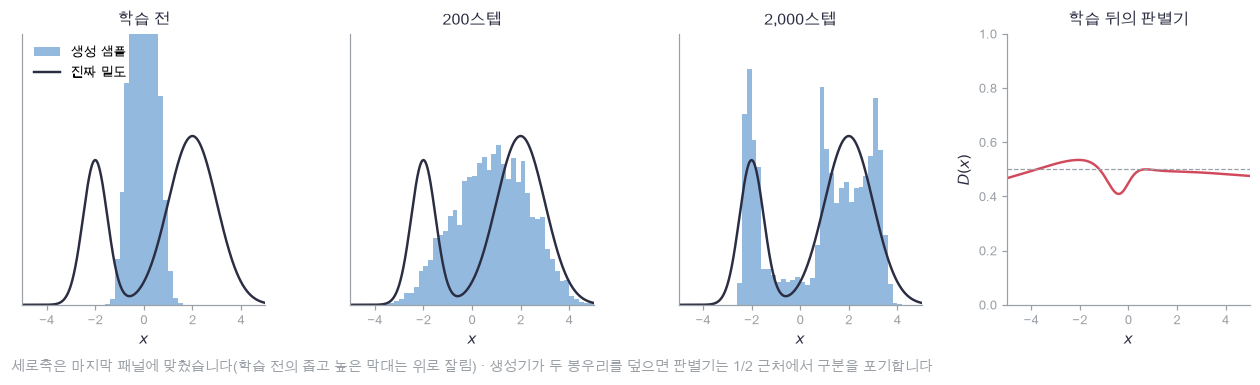

In [41]:
# 쓰는 것: gan1d_before, gan1d_snaps, gan1d_d (3절 학습 셀) · opt_x, opt_p_data, opt_view (3절 계산 셀) · mlp_forward (2절) · sigmoid (1절)
gan1d_curve = sigmoid(mlp_forward(opt_x[opt_view][:, None], gan1d_d)[0][:, 0])    # (2001,): 학습이 끝난 판별기 D(x)
plot_gan_1d(opt_x[opt_view], opt_p_data[opt_view],
            [("학습 전", gan1d_before), ("200스텝", gan1d_snaps[200][:, 0]), ("2,000스텝", gan1d_snaps[1999][:, 0])],
            gan1d_curve, np.linspace(-6, 6, 61))

🔍 **확인** · 학습 전에는 생성 샘플이 0 근처에 좁게 뭉쳐 있습니다(세로축을 마지막 패널에 맞췄기 때문에 그 막대는 위로 잘렸습니다). 200스텝에서는 오른쪽 큰 봉우리를 먼저 찾아가고, 2,000스텝에서는 두 봉우리의 높이와 폭이 모두 검은 진짜 밀도와 겹칩니다.
마지막 패널의 판별기는 0.41에서 0.53 사이에서 거의 평평합니다. 구분할 수 없어 **1/2 근처에서 포기한** 상태이고, 이것이 균형점의 모습입니다. 손실도 $2\log2$와 $\log2$에서 0.01 안쪽입니다.
생성 샘플의 평균 0.83과 표준편차 1.98이 닫힌식 0.80과 2.03에 가깝고, 봉우리별 비율도 $(0.29,0.71)$로 $\pi=(0.3,0.7)$과 맞습니다. 이 모든 값을 GAN은 **밀도를 한 번도 쓰지 않고** 표본만 보고 맞혔습니다. 학습용 작은 문제의 결과이며 실제 데이터의 성능이 아닙니다.

### ✏️ 연습 3 · 균형점에서 두 손실의 값

교대 갱신이 도착하려는 자리가 균형점입니다. 그 자리에서는 $p_g=p_{data}$라 판별기가 모든 표본에 $D=1/2$, 즉 **logit 0**을 냅니다. `zeros`는 미리 만들어 두었으니 그때의 판별기 손실 `d_loss`와 생성기 손실 `g_loss` 두 줄을 채우세요. 검사는 닫힌식 $2\log2$와 $\log2$로 합니다.

In [42]:
def exercise_equilibrium_losses(batch):
    """연습 3: 모든 logit 이 0(= D 가 1/2)일 때의 판별기·생성기 손실. batch: 표본 수 → (d_loss, g_loss) 숫자 둘."""
    assert batch >= 1, "표본 수는 1 이상이어야 합니다"
    zeros = np.zeros((batch, 1))                                     # (batch, 1): D(x) = 1/2 이 되는 logit
    ### 이 주석 아래에 다음을 구현하세요.
    ### 구현할 내용: d_loss = 진짜·가짜 모두 logit 이 zeros 일 때의 판별기 손실, g_loss = 같은 자리의 non-saturating 생성기 손실
    ### 힌트: 1절의 discriminator_loss(zeros, zeros) 와 generator_loss(zeros) 는 (손실, 기울기…) 를 돌려줍니다. 첫 번째 값만 쓰세요.
    raise NotImplementedError
    return d_loss, g_loss

In [43]:
def check_equilibrium_losses(candidate):
    """표본 수 1개와 7개에서 닫힌식 2 log 2, log 2 와 대조합니다. 통과하면 메시지를 출력합니다."""
    for batch in (1, 7):
        d_loss, g_loss = candidate(batch)
        assert np.ndim(d_loss) == 0, f"판별기 손실은 숫자 하나여야 하는데 모양이 {np.shape(d_loss)} 입니다"
        np.testing.assert_allclose(d_loss, 2 * np.log(2))            # 검산: −log(1/2) 두 개 = 2 log 2 = 1.3863
        np.testing.assert_allclose(g_loss, np.log(2))                # 검산: −log(1/2) 하나 = log 2 = 0.6931
    print("균형점의 두 손실: 닫힌식 2 log 2 와 log 2 와 일치합니다.")


run_check(check_equilibrium_losses, exercise_equilibrium_losses,
          hint="d_loss = discriminator_loss(zeros, zeros)[0] · g_loss = generator_loss(zeros)[0]")

☐ exercise_equilibrium_losses: 아직 채우지 않았습니다. `raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓰세요.
   힌트: d_loss = discriminator_loss(zeros, zeros)[0] · g_loss = generator_loss(zeros)[0]


📎 **정답** · 막히면 펼쳐 보고, 다시 접고 스스로 써 보세요.

<details>
<summary>정답 보기</summary>

```python
d_loss = discriminator_loss(zeros, zeros)[0]
g_loss = generator_loss(zeros)[0]
```

</details>

## 🔑 4. mode 붕괴: 봉우리별로 세면 숫자가 됩니다

**이 절에서 가져갈 것:** 생성 샘플 하나하나를 진짜 혼합의 책임확률이 가장 큰 봉우리에 배정해 세면, "한 봉우리만 만든다"는 mode 붕괴가 개수 표로 드러납니다. 판별기가 너무 약하면 생성기가 한 봉우리만 만들고도 벌을 받지 않아서, 같은 코드가 seed 에 따라 붕괴하기도 하고 안 하기도 합니다.

3절의 1차원 GAN은 두 봉우리를 잘 덮었습니다. 그런데 그림만 보고 "덮었다"고 말하는 것은 눈대중입니다.
2차원으로 옮겨 가면 눈대중은 더 어려워집니다. 진짜 혼합은 왼쪽 아래와 오른쪽 위 두 덩어리인데, 생성 샘플이 한쪽에만 몰려 있어도 산점도만 보면 "그럴듯한 점들"로 보일 수 있습니다.
진짜 분포의 책임확률을 알고 있으니, 생성 샘플마다 "어느 봉우리에서 왔다고 보아야 하는가"를 물어 개수를 세면 눈대중이 숫자가 됩니다.

> **용어**
>
> - **mode(봉우리)**: 밀도가 국소적으로 가장 높은 자리. 두 봉우리 혼합에는 mode 가 둘입니다.
> - **mode 붕괴(mode collapse)**: 생성기가 데이터의 일부 봉우리만 만들고 나머지를 버리는 현상. 판별기를 속이는 데는 한 봉우리로도 충분할 수 있어서 생깁니다.
> - **coverage(덮음)**: 생성 분포가 진짜 분포의 봉우리들을 고루 덮는 정도. 여기서는 봉우리별 개수 비율을 진짜 비율 $\pi$와 견주어 잽니다.

생성 샘플 $\hat x_m$을 책임확률이 가장 큰 봉우리에 배정하고, 봉우리마다 몇 개가 배정됐는지 셉니다. $M$개를 뽑았다면 봉우리 $k$의 기대 개수는 $M\pi_k$입니다.

$$k(\hat x)=\arg\max_{k}\;r_k(\hat x),\qquad
n_k=\#\{m:\;k(\hat x_m)=k\},\qquad \sum_k n_k=M.$$

배정은 빠짐없이 한 번씩이므로 개수의 합은 언제나 표본 수와 같습니다. 그래서 "봉우리 1이 4,000개, 봉우리 2가 0개"는 곧바로 붕괴를 뜻합니다.
아래에서는 학습을 하기 전에, **손으로 만든** 두 구름으로 이 세는 방법이 무엇을 잡아내는지 먼저 봅니다. 하나는 두 봉우리를 모두 덮는 구름, 다른 하나는 한 봉우리에만 몰린 구름입니다.

> **코드**
>
> - `np.bincount(labels, minlength=2)`: 0·1 로 된 배열에서 각 값이 몇 번 나왔는지 셉니다. `minlength=2`는 한쪽이 0개여도 길이 2인 배열을 돌려주게 합니다.
> - `np.meshgrid(a, b)`: 두 축의 격자를 만들어 `(len(b), len(a))` 두 장으로 돌려줍니다. 등고선을 그릴 좌표판입니다.
> - `np.stack([xx.ravel(), yy.ravel()], axis=1)`: 격자 두 장을 펴서 `(격자칸 수, 2)` 점 목록으로 만듭니다.

In [44]:
# 쓰는 것: mix2_sample, mix2_responsibility (📎 혼합 셀) · MIX2_MU, MIX2_PI (📎 상수 셀)
count_rng = np.random.default_rng(41)
count_real = mix2_sample(2000, count_rng)                            # (2000, 2): 진짜 샘플
count_cover = mix2_sample(2000, count_rng) + np.array([0.3, -0.2])   # (2000, 2): 두 봉우리를 덮지만 조금 어긋난 구름
count_collapse = MIX2_MU[1] + 0.5 * count_rng.normal(size=(2000, 2))  # (2000, 2): 봉우리 2 에만 몰린 구름
count_clouds = [count_real, count_cover, count_collapse]
count_assign = [mix2_responsibility(X).argmax(axis=1) for X in count_clouds]      # 구름마다 (2000,) 배정
count_table = np.array([np.bincount(a, minlength=2) for a in count_assign])       # (3, 2): 구름 × 봉우리 개수
print("개수 표 (행 = 진짜·덮음·몰림):\n", count_table, "\n합", count_table.sum(axis=1), "· 기대 개수", (2000 * MIX2_PI).round(0))

개수 표 (행 = 진짜·덮음·몰림):
 [[ 770 1230]
 [ 800 1200]
 [   0 2000]] 
합 [2000 2000 2000] · 기대 개수 [ 800. 1200.]


In [45]:
# 쓰는 것: mix2_responsibility (📎 혼합 셀)
count_axis = np.linspace(-5, 5, 161)                                 # (161,): 등고선용 한 축
count_xx, count_yy = np.meshgrid(count_axis, count_axis)             # (161, 161) 두 장
count_points = np.stack([count_xx.ravel(), count_yy.ravel()], axis=1)    # (25921, 2): 격자칸을 점 목록으로
count_r1 = mix2_responsibility(count_points)[:, 0].reshape(count_xx.shape)   # (161, 161): 봉우리 1 의 책임확률
np.testing.assert_allclose(mix2_responsibility(count_points).sum(axis=1), 1.0)   # 검산: 격자 어디서나 책임확률 합 = 1
print("책임확률 격자", count_r1.shape, "· 최솟값", count_r1.min().round(4), "· 최댓값", count_r1.max().round(4))

책임확률 격자 (161, 161) · 최솟값 0.0 · 최댓값 1.0


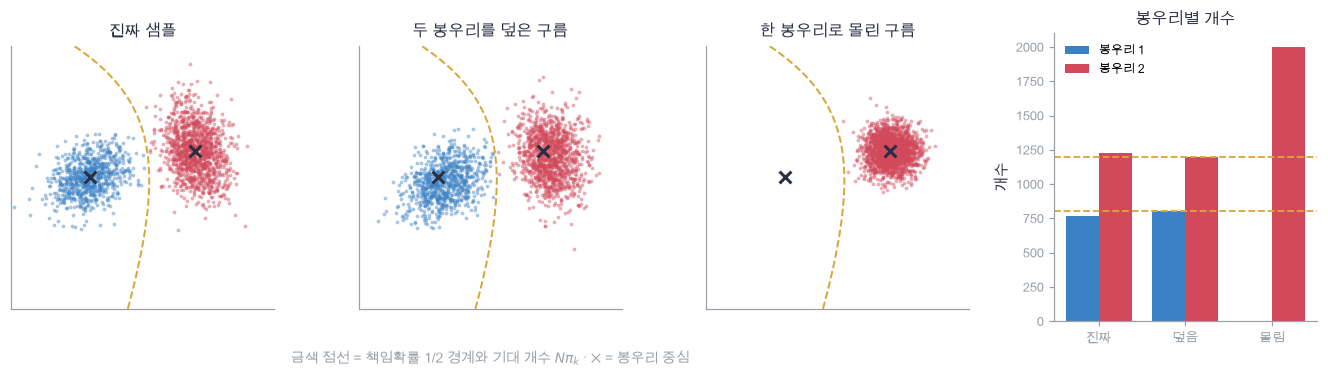

In [46]:
plot_mode_counting(count_clouds, ["진짜 샘플", "두 봉우리를 덮은 구름", "한 봉우리로 몰린 구름"],
                   count_assign, count_table, ["진짜", "덮음", "몰림"], MIX2_MU,
                   (count_xx, count_yy, count_r1), 2000 * MIX2_PI)

🔍 **확인** · 금색 점선이 책임확률 1/2 의 경계입니다. 이 선을 기준으로 왼쪽 아래는 봉우리 1(파랑), 오른쪽 위는 봉우리 2(빨강)로 배정됩니다.
가운데 구름은 조금 어긋났지만 두 봉우리를 모두 덮어서 개수가 금색 점선(기대 개수 $2000\pi_k$ = 800, 1200)과 정확히 맞습니다. 오른쪽 구름은 전부 빨강이고, 막대에서 파란 쪽이 0입니다.
산점도만 보면 오른쪽 구름도 "점이 뭉쳐 있는 그럴듯한 그림"이지만, 개수를 세면 봉우리 하나를 통째로 잃었다는 사실이 한눈에 드러납니다.
아래 구현은 이 배정과 세기를 함수 하나로 묶습니다. 그다음 같은 설정을 seed 세 개로 학습해 실제 GAN 이 어떻게 되는지 봅니다.

In [47]:
def count_modes(X):
    """생성 샘플을 진짜 혼합의 책임확률이 가장 큰 봉우리에 배정해 셉니다 (23번 2절).
    X: (M, 2) → (labels: (M,) 값 0 또는 1, counts: (2,) 정수)."""
    # 쓰는 것: mix2_responsibility (📎 혼합 셀)
    labels = mix2_responsibility(X).argmax(axis=1)                   # (M,): 책임확률이 큰 쪽
    return labels, np.bincount(labels, minlength=2)

In [48]:
def run_mix2_gan(seed, d_sizes, lr_d, lr_g, steps=1200):
    """2차원 혼합에서 GAN 을 한 번 학습합니다. G 는 [2, 64, 2] 로 고정하고 판별기 크기·학습률만 바꿉니다.
    seed: 정수, d_sizes: 판별기 층 크기 목록 → (samples: (4000, 2), history: 손실 기록)."""
    # 쓰는 것: init_mlp (2절) · gan_train (3절) · mix2_sample (📎 혼합 셀)
    rng = np.random.default_rng(300 + seed)
    g_params = init_mlp([2, 64, 2], rng)
    d_params = init_mlp(d_sizes, rng)
    history, snaps = gan_train(mix2_sample, g_params, d_params, steps, 256, 2, rng,
                               lr_d=lr_d, lr_g=lr_g, snapshots=(steps - 1,))
    return snaps[steps - 1], history

In [49]:
# 쓰는 것: run_mix2_gan, count_modes (4절)
mode_settings = [("균형", [2, 64, 1], 2e-3, 2e-3),                   # D 가 G 와 같은 폭이고 학습률도 같음
                 ("약한 D", [2, 16, 1], 5e-4, 5e-3)]                 # D 를 좁고 느리게, G 만 빠르게 밀어 일부러 불균형하게
mode_samples = {}
mode_counts = []
mode_labels = []
for name, d_sizes, lr_d, lr_g in mode_settings:
    mode_samples[name] = []
    for seed in (1, 2, 3):
        gen_samples, _ = run_mix2_gan(seed, d_sizes, lr_d, lr_g)     # (4000, 2)
        mode_samples[name].append(gen_samples)
        mode_counts.append(count_modes(gen_samples)[1])
        mode_labels.append(f"{name}·seed {seed}")
mode_counts = np.array(mode_counts)                                  # (6, 2): 설정×seed 마다 봉우리 개수
print("설정별 개수:\n", np.array2string(mode_counts), "\n라벨", mode_labels)

설정별 개수:
 [[1575 2425]
 [1707 2293]
 [1665 2335]
 [   0 4000]
 [ 313 3687]
 [1690 2310]] 
라벨 ['균형·seed 1', '균형·seed 2', '균형·seed 3', '약한 D·seed 1', '약한 D·seed 2', '약한 D·seed 3']


In [50]:
# 쓰는 것: mode_counts (4절 실험 셀) · MIX2_PI (📎 상수 셀)
mode_fractions = mode_counts / mode_counts.sum(axis=1, keepdims=True)    # (6, 2): 비율
assert np.all(mode_counts.sum(axis=1) == 4000), "배정은 빠짐없이 한 번씩이라 개수 합이 표본 수 4,000 과 같아야 합니다"
np.testing.assert_allclose(mode_fractions[:3], np.tile(MIX2_PI, (3, 1)), atol=0.05)   # 검산: 균형 설정 seed 3개의 비율 ≈ π = (0.4, 0.6)
assert mode_fractions[3:].min() < 0.05, "약한 D 설정에는 한 봉우리를 거의 만들지 못하는 seed 가 있어야 합니다"
print("균형 설정 비율\n", mode_fractions[:3].round(3), "\n약한 D 설정 비율\n", mode_fractions[3:].round(3), "\nπ =", MIX2_PI)

균형 설정 비율
 [[0.394 0.606]
 [0.427 0.573]
 [0.416 0.584]] 
약한 D 설정 비율
 [[0.    1.   ]
 [0.078 0.922]
 [0.422 0.578]] 
π = [0.4 0.6]


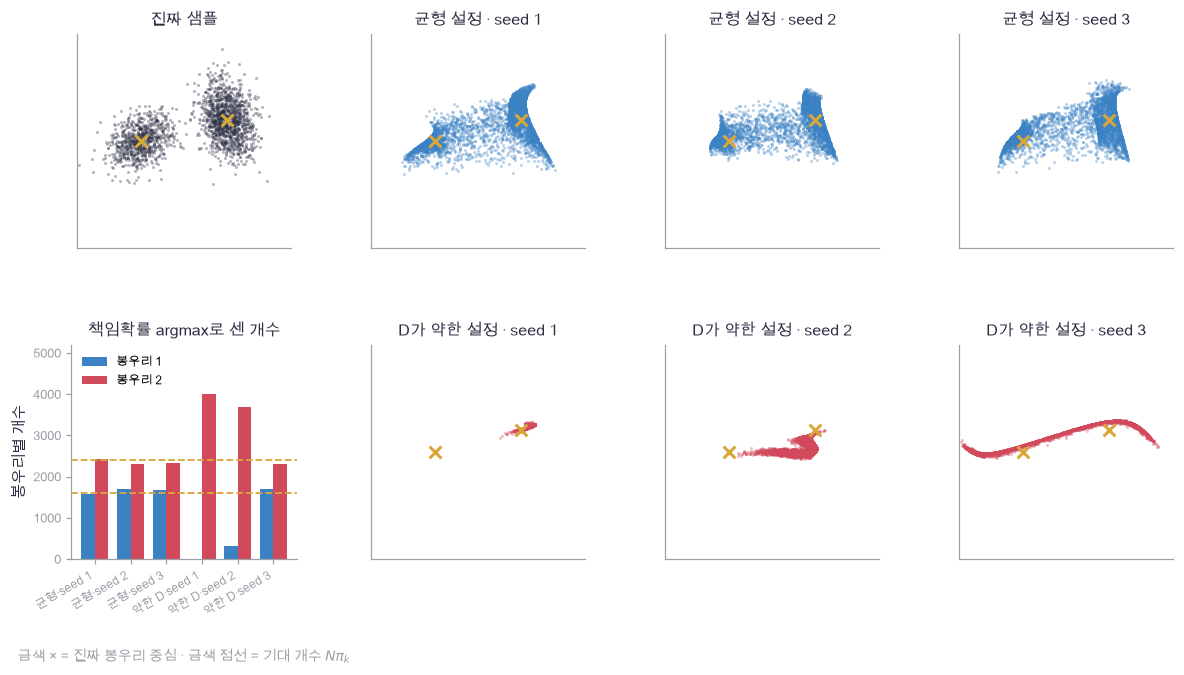

In [51]:
# 쓰는 것: count_real (4절 계산 셀) · mode_samples, mode_counts, mode_labels (4절 실험 셀) · MIX2_MU, MIX2_PI (📎 상수 셀)
plot_mode_coverage(count_real, mode_samples["균형"], mode_samples["약한 D"],
                   mode_counts, mode_labels, MIX2_MU, expected=4000 * MIX2_PI)

🔍 **확인** · 위 줄의 균형 설정은 seed 세 개 모두 두 중심을 지나가고, 막대가 금색 점선(기대 개수 1,600과 2,400)에 붙습니다. 비율이 $(0.39,0.61)$ 부터 $(0.43,0.57)$ 까지로 $\pi=(0.4,0.6)$ 과 0.05 안쪽입니다. 다만 진짜처럼 두 덩어리로 **갈라지지는 않고** 하나로 이어진 띠 모양입니다. 생성기가 이어진 함수 $G(z)$ 하나라 사이를 끊기 어렵기 때문입니다.
아래 줄의 약한 판별기 설정은 seed 마다 결과가 갈립니다. seed 1 은 오른쪽 봉우리에 거의 한 점으로 뭉쳐 파란 막대가 0 이고, seed 2 도 봉우리 1 이 8%뿐입니다. seed 3 은 개수로는 두 봉우리를 덮었지만 그림을 보면 **두께 없는 가는 곡선**이라, 개수만으로는 잡히지 않는 실패도 있다는 것을 함께 보여 줍니다. 같은 코드, 같은 데이터인데 초기값만 달라도 이렇게 갈립니다.
판별기가 생성기를 따라가지 못하면 한 봉우리만 만들어도 점수를 잘 받습니다. 벌이 없으니 나머지 봉우리를 찾을 이유가 없고, 이것이 mode 붕괴입니다. GAN 이 까다롭다는 말의 상당 부분이 이 그림입니다.
mode 붕괴를 재려면 이렇게 **진짜 분포를 알아야** 합니다. 5절의 MNIST 에서는 밀도 대신 클래스 평균 최근접으로 같은 세기를 흉내 냅니다.

### ✏️ 연습 4 · 책임확률이 가장 큰 봉우리에 배정하기

생성 샘플 `X` `(M, 2)`를 진짜 혼합의 책임확률이 가장 큰 봉우리에 배정하는 한 줄을 채우세요. 결과는 값이 0 또는 1 인 `(M,)` 배열입니다. 검사는 봉우리 중심 바로 위의 점들과 4절 계산 셀의 개수 표로 합니다.

In [52]:
def exercise_assign_mode(X):
    """연습 4: 2차원 점을 책임확률이 가장 큰 봉우리 번호로 배정합니다. X: (M, 2) → labels: (M,) 값 0 또는 1."""
    assert X.shape[1] == 2, "2차원 점이어야 합니다"
    ### 이 주석 아래에 다음을 구현하세요.
    ### 구현할 내용: labels = 책임확률 (M, 2) 에서 행마다 가장 큰 성분의 번호 (모양 (M,))
    ### 힌트: 4절 count_modes 의 첫 줄입니다. mix2_responsibility(X) 뒤에 .argmax(axis=1) 을 붙입니다.
    raise NotImplementedError
    return labels

In [53]:
def check_assign_mode(candidate):
    """봉우리 중심 두 점의 손계산과 4절 계산 셀의 개수 표로 검사합니다. 통과하면 메시지를 출력합니다."""
    # 쓰는 것: MIX2_MU (📎 상수 셀) · count_clouds, count_table (4절 계산 셀)
    centers = np.array([MIX2_MU[0], MIX2_MU[1], [-2.0, 0.1]])        # (3, 2): 봉우리 1, 봉우리 2, 봉우리 1 바로 옆
    np.testing.assert_allclose(candidate(centers), [0, 1, 0])        # 검산: 중심에서는 자기 봉우리로 배정
    for cloud, row in zip(count_clouds, count_table):
        np.testing.assert_allclose(np.bincount(candidate(cloud), minlength=2), row)   # 검산: 4절 개수 표와 같음
    print("봉우리 배정: 손계산·4절 개수 표와 일치합니다.")


run_check(check_assign_mode, exercise_assign_mode, hint="labels = mix2_responsibility(X).argmax(axis=1)")

☐ exercise_assign_mode: 아직 채우지 않았습니다. `raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓰세요.
   힌트: labels = mix2_responsibility(X).argmax(axis=1)


📎 **정답** · 막히면 펼쳐 보고, 다시 접고 스스로 써 보세요.

<details>
<summary>정답 보기</summary>

```python
labels = mix2_responsibility(X).argmax(axis=1)
```

</details>

## 🔑 5. MNIST PCA-32 좌표에서 학습하기

**이 절에서 가져갈 것:** 784개 화소 대신 PCA 좌표 32개에서 학습하면 1·2차원에서 쓴 **같은 코드**가 몇 초 만에 돌고, 생성한 좌표는 고정된 기저 $Q$로 되돌려 28×28 이미지가 됩니다. 봉우리 대신 숫자 0–9 를 세면 coverage 를 같은 방식으로 잽니다.

지금까지의 상황은 봉우리가 둘인 장난감 분포였습니다. 손글씨 숫자로 옮기면 "봉우리"가 열 개(숫자 0–9)이고 차원이 784 입니다.
784차원에서 MLP 두 개를 돌리면 이 노트북의 예산을 넘습니다. 그래서 11번의 PCA 로 좌표를 32개로 줄여 그 공간에서 학습합니다. 생성기가 만드는 것은 이미지가 아니라 **좌표 32개**이고, 이미지는 고정된 기저를 곱해 되돌립니다.

> **용어**
>
> - **PCA 좌표**: 데이터의 분산이 큰 방향 32개 $Q$ 위로 내린 좌표 $z=(x-\mu)Q/s$ (11번 3·4절). $s$는 좌표 전체의 표준편차로, 1·2차원 상황과 규모를 맞추려고 나눕니다.
> - **기저 이미지**: $Q$의 열 하나를 28×28 로 되돌린 그림. 모든 복원 이미지는 이 32장의 가중합에 평균 이미지를 더한 것입니다.
> - **디코딩(decoding)**: 좌표를 원래 공간으로 되돌리는 것. 여기서는 $\hat x=z\,s\,Q^\top+\mu$ 한 줄이며 학습하지 않는 고정 변환입니다.
> - **클래스 평균 최근접**: 좌표 공간에서 숫자별 평균에 가장 가까운 숫자로 분류하는 방법 (00b 5절). 밀도가 없는 MNIST 에서 4절의 책임확률 배정을 대신합니다.

$\mu$는 앞 5,000장의 평균 이미지 $(784,)$, $Q$는 공분산 $C=X_c^\top X_c/N$의 고유벡터 중 고윳값이 큰 32개 $(784,32)$입니다 (11번 2·3절).

$$Z=\frac{(X-\mu)Q}{s}\in\mathbb R^{5000\times32},\qquad \hat X=Z\,s\,Q^\top+\mu\in\mathbb R^{5000\times784},\qquad s=\operatorname{std}\big((X-\mu)Q\big).$$

생성기는 $\mathbb R^{16}\to\mathbb R^{32}$, 판별기는 $\mathbb R^{32}\to\mathbb R$ 입니다. 은닉 폭은 128, 활성화는 ReLU 입니다.

> **코드**
>
> - `np.linalg.eigh(C)`: 대칭 행렬의 고윳값·고유벡터를 **오름차순**으로 돌려줍니다 (11번 3절). 큰 것부터 쓰려면 뒤집어야 합니다.
> - `mnist_eigvecs[:, ::-1][:, :32]`: 열 순서를 뒤집어 큰 고윳값부터 오게 한 뒤 앞 32열을 고릅니다.
> - `rng.integers(0, N, size=n)`: 0 부터 N−1 까지 정수 n 개를 무작위로. 같은 번호가 두 번 나올 수 있는 **복원추출**입니다 (01b 2절).

In [54]:
mnist_examples, mnist_labels = load_examples(download=True)          # (10, 28, 28), (10,): 고정 예시 10장
mnist_X_all, mnist_y_all, _, _ = load_mnist(download=True)           # (60000, 784), (60000,)
mnist_X = mnist_X_all[:5000]                                         # (5000, 784): 이 프로젝트의 학습용 관례
mnist_y = mnist_y_all[:5000]                                         # (5000,)
mnist_mu = mnist_X.mean(axis=0)                                      # (784,): 평균 이미지
mnist_centered = mnist_X - mnist_mu                                  # (5000, 784)
mnist_cov = mnist_centered.T @ mnist_centered / len(mnist_X)         # (784, 784): 공분산 (11번 2절)
mnist_eigvals, mnist_eigvecs = np.linalg.eigh(mnist_cov)             # 고윳값 오름차순 (11번 3절)
mnist_Q = mnist_eigvecs[:, ::-1][:, :32]                             # (784, 32): 분산이 큰 32방향
mnist_scale = float((mnist_centered @ mnist_Q).std())                # 좌표 전체의 표준편차 하나
mnist_Z = (mnist_centered @ mnist_Q) / mnist_scale                   # (5000, 32): 단위 규모 좌표
mnist_kept = float(mnist_eigvals[::-1][:32].sum() / mnist_eigvals.sum())
print(f"좌표 {mnist_Z.shape} · 규모 s = {mnist_scale:.4f} · 좌표 표준편차 {mnist_Z.std():.4f} · 32방향이 남긴 분산 {mnist_kept:.1%}")

좌표 (5000, 32) · 규모 s = 1.1101 · 좌표 표준편차 1.0000 · 32방향이 남긴 분산 74.9%


In [55]:
def decode_coords(Z):
    """좌표를 28×28 이미지로 되돌립니다: x̂ = z·s·Qᵀ + μ (11번 4절). Z: (N, 32) → (N, 28, 28)."""
    # 쓰는 것: mnist_scale, mnist_Q, mnist_mu (5절 PCA 셀)
    return ((Z * mnist_scale) @ mnist_Q.T + mnist_mu).reshape(-1, 28, 28)

In [56]:
# 쓰는 것: mnist_examples (5절 데이터 셀) · mnist_mu, mnist_Q, mnist_scale, mnist_Z, mnist_X, mnist_kept (5절 PCA 셀) · decode_coords (5절)
mnist_seven = mnist_examples[7]                                      # (28, 28): 00번부터 쓰는 고정 예시 7
seven_coords = ((mnist_seven.reshape(-1) - mnist_mu) @ mnist_Q) / mnist_scale    # (32,): 7 의 좌표
seven_recon = decode_coords(seven_coords[None])[0]                   # (28, 28): 좌표만으로 되돌린 7
mnist_recon_rms = float(np.sqrt(np.mean((decode_coords(mnist_Z) - mnist_X.reshape(-1, 28, 28)) ** 2)))
np.testing.assert_allclose(decode_coords(np.zeros((1, 32)))[0], mnist_mu.reshape(28, 28))   # 검산: 좌표 0 이면 평균 이미지
mnist_one_hot = np.zeros((1, 32))
mnist_one_hot[0, 0] = 1.0                                            # (1, 32): 첫 좌표만 1 인 좌표
np.testing.assert_allclose(decode_coords(mnist_one_hot)[0], (mnist_scale * mnist_Q[:, 0] + mnist_mu).reshape(28, 28))   # 검산: 좌표 1 이면 μ + s·q_0
assert mnist_recon_rms < 0.15, "32개 좌표로 되돌린 이미지의 화소 RMS 오차가 0.15 아래여야 합니다"
print(f"7 의 좌표 앞 4개 {seven_coords[:4].round(2)} · 5,000장 복원 화소 RMS 오차 {mnist_recon_rms:.4f}")

7 의 좌표 앞 4개 [ 2.52 -1.23  0.86  1.16] · 5,000장 복원 화소 RMS 오차 0.1298


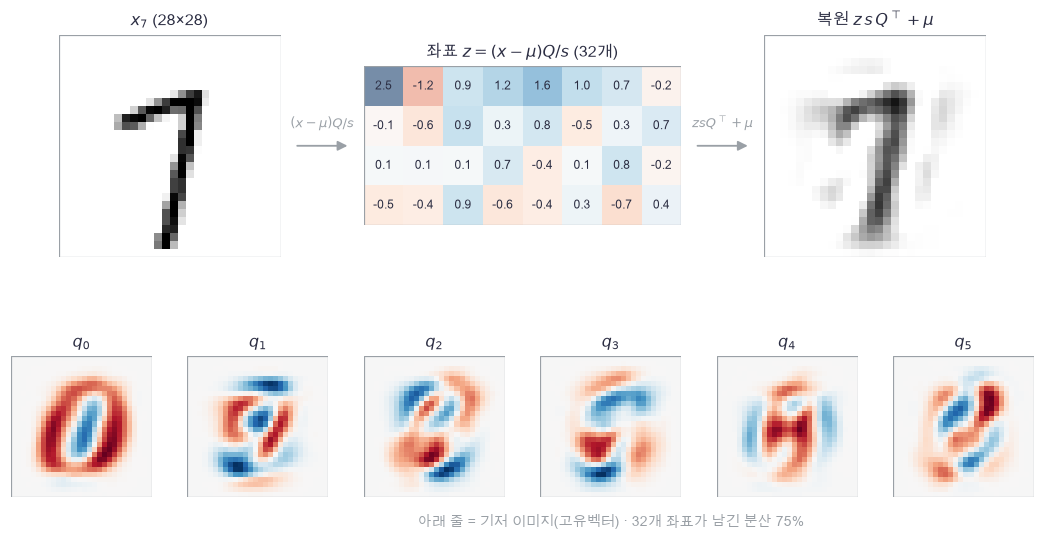

In [57]:
plot_pca_roundtrip(mnist_seven, seven_coords, seven_recon, mnist_Q[:, :6].T.reshape(6, 28, 28), mnist_kept)

🔍 **확인** · 왼쪽의 7 이 가운데 숫자 32개가 되고, 오른쪽에서 다시 7 로 돌아옵니다. 가운데 32칸이 생성기가 만들어야 할 전부이고, 오른쪽 화살표의 식은 학습하지 않는 고정 변환입니다.
아래 줄이 기저 이미지 여섯 장입니다. 복원된 7 은 이런 그림 32장을 좌표만큼 섞어 평균 이미지에 더한 것입니다. 획이 조금 뭉개지는 이유는 32방향이 전체 분산의 75%만 남기기 때문입니다.
5,000장 전체의 복원 화소 오차가 0.13 이니, 32개 좌표만 잘 만들면 "그럴듯한 숫자"가 나올 여지가 있습니다.
아래부터는 이 좌표 공간에서 1·2차원과 **완전히 같은** `gan_train` 을 돌립니다. 달라지는 것은 층 크기와 활성화뿐입니다.

In [58]:
# 쓰는 것: mnist_Z, mnist_y (5절 PCA 셀)
mnist_class_mean = np.stack([mnist_Z[mnist_y == c].mean(axis=0) for c in range(10)])   # (10, 32): 숫자별 좌표 평균


def nearest_class(Z):
    """좌표를 가장 가까운 클래스 평균의 숫자로 (00b 5절의 전개식 ‖z‖² − 2 z·m + ‖m‖²). Z: (N, 32) → (N,) 값 0–9."""
    # 쓰는 것: mnist_class_mean (5절)
    distances = (Z ** 2).sum(axis=1)[:, None] - 2 * Z @ mnist_class_mean.T + (mnist_class_mean ** 2).sum(axis=1)
    return distances.argmin(axis=1)

In [59]:
def sample_mnist_real(n, rng):
    """앞 5,000장의 좌표에서 n 개를 복원추출로 뽑습니다 (01b 2절의 미니배치). n: 개수 → (n, 32)."""
    # 쓰는 것: mnist_Z (5절 PCA 셀)
    return mnist_Z[rng.integers(0, len(mnist_Z), size=n)]

In [60]:
# 쓰는 것: init_mlp (2절) · gan_train (3절) · sample_mnist_real, mnist_Z (5절)
mnist_rng = np.random.default_rng(2800)
mnist_g = init_mlp([16, 128, 32], mnist_rng)                         # G: 잠재 16 → 은닉 128 → 좌표 32
mnist_d = init_mlp([32, 128, 1], mnist_rng)                          # D: 좌표 32 → 은닉 128 → logit 1
mnist_history, mnist_snaps = gan_train(sample_mnist_real, mnist_g, mnist_d, 3000, 128, 16, mnist_rng,
                                       lr_d=1e-3, lr_g=1e-3, activation="relu", snapshots=(2999,))
mnist_gen = mnist_snaps[2999]                                        # (4000, 32): 학습이 끝난 뒤 생성한 좌표
print(f"마지막 200스텝 평균 손실 L_D {np.mean(mnist_history['d'][-200:]):.3f} · L_G {np.mean(mnist_history['g'][-200:]):.3f}"
      f" · 생성 좌표 {mnist_gen.shape} 표준편차 {mnist_gen.std():.3f} (진짜 {mnist_Z.std():.3f})")

마지막 200스텝 평균 손실 L_D 1.120 · L_G 1.023 · 생성 좌표 (4000, 32) 표준편차 0.994 (진짜 1.000)


In [61]:
# 쓰는 것: mnist_gen (5절 학습 셀) · mnist_Z (5절 PCA 셀) · nearest_class (5절)
mnist_gen_counts = np.bincount(nearest_class(mnist_gen), minlength=10)    # (10,): 생성 샘플의 숫자별 개수
mnist_real_counts = np.bincount(nearest_class(mnist_Z), minlength=10)     # (10,): 진짜 5,000장의 숫자별 개수
assert mnist_gen_counts.sum() == len(mnist_gen), "배정은 빠짐없이 한 번씩이라 개수 합이 표본 수와 같아야 합니다"
assert mnist_gen_counts.min() > 100, "숫자 열 가지가 모두 100장 넘게 나와야 합니다 (mode 붕괴가 아님)"
assert abs(mnist_gen.std() - 1.0) < 0.2, "생성 좌표의 전체 표준편차가 진짜와 같은 1 근처여야 합니다"
print("생성 숫자별 개수", mnist_gen_counts, "\n진짜 숫자별 개수", mnist_real_counts,
      "\n가장 적은 숫자", int(mnist_gen_counts.argmin()), "·", int(mnist_gen_counts.min()), "장")

생성 숫자별 개수 [285 476 318 442 393 505 350 247 366 618] 
진짜 숫자별 개수 [464 749 428 496 547 388 482 518 399 529] 
가장 적은 숫자 7 · 247 장


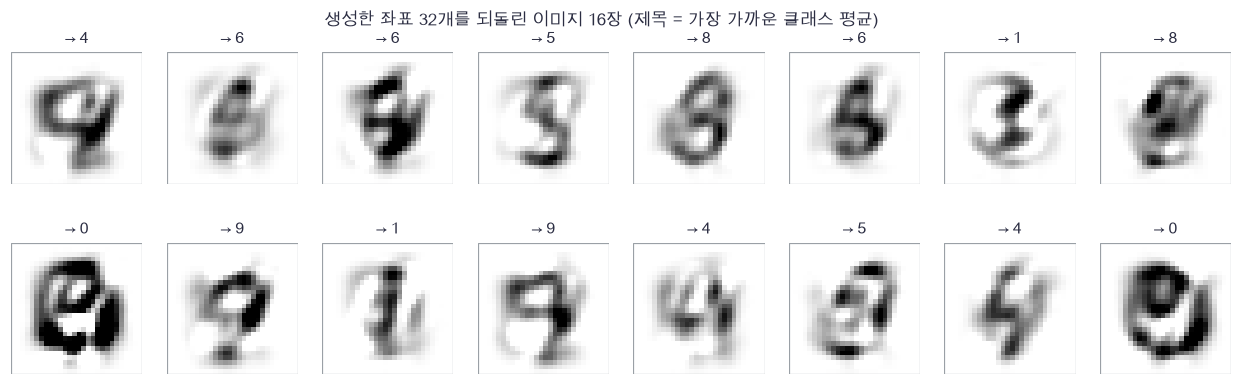

In [62]:
# 쓰는 것: mnist_gen (5절 학습 셀) · decode_coords, nearest_class (5절)
mnist_images = np.clip(decode_coords(mnist_gen[:16]), 0, 1)          # (16, 28, 28): 0–1 잉크로 자른 생성 이미지
mnist_image_labels = [f"→ {digit}" for digit in nearest_class(mnist_gen[:16])]
plot_generated_images(mnist_images, mnist_image_labels, "생성한 좌표 32개를 되돌린 이미지 16장 (제목 = 가장 가까운 클래스 평균)")

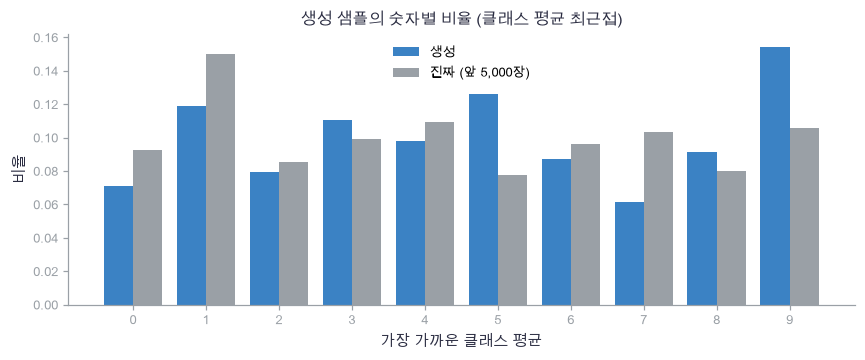

In [63]:
plot_digit_counts(mnist_gen_counts, mnist_real_counts)

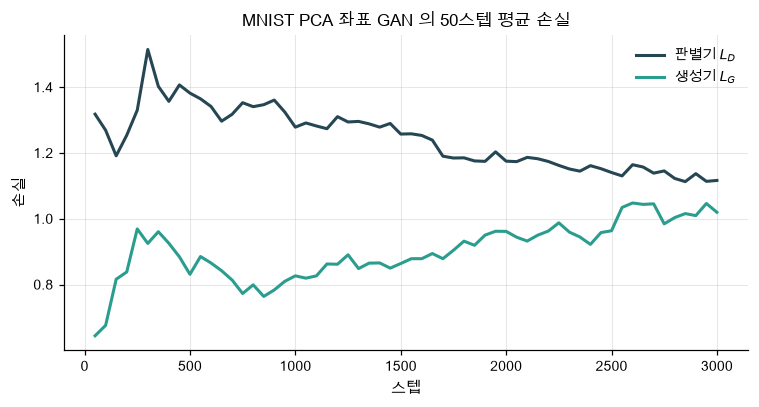

In [64]:
# 쓰는 것: mnist_history (5절 학습 셀)
mnist_window = 50                                                    # 손실이 스텝마다 크게 흔들려 50스텝 평균으로 봅니다
mnist_curve_steps = np.arange(mnist_window, 3001, mnist_window)      # (60,)
mnist_d_curve = [float(np.mean(mnist_history["d"][s - mnist_window:s])) for s in mnist_curve_steps]
mnist_g_curve = [float(np.mean(mnist_history["g"][s - mnist_window:s])) for s in mnist_curve_steps]
plot_curves(mnist_curve_steps, {"판별기 $L_D$": mnist_d_curve, "생성기 $L_G$": mnist_g_curve},
            title="MNIST PCA 좌표 GAN 의 50스텝 평균 손실", ylabel="손실")

🔍 **확인** · 이미지 16장에는 9·3·5·8 처럼 알아볼 만한 획과, 두 숫자 사이에서 멈춘 애매한 그림이 섞여 있습니다. 32개 좌표로 줄인 탓에 획이 흐리고, 3,000스텝의 작은 모델이라 선명하지 않습니다. **학습용 작은 문제의 결과**이며 실제 이미지 생성 모델의 품질로 읽으면 안 됩니다. 제목의 숫자는 좌표 공간에서 가장 가까운 클래스 평균일 뿐이라 눈에 보이는 숫자와 다를 수 있습니다.
막대 그림에서는 열 가지 숫자가 모두 나옵니다. 가장 적은 숫자(7)도 4,000장 중 247장이라 4절의 붕괴와는 다릅니다. 다만 진짜 비율과 견주면 7은 0.6배, 5는 1.6배라 고르지는 않습니다.
손실 곡선은 판별기 쪽이 1.32 에서 시작해 1.51 까지 올랐다가 1.12 로 내려가고, 생성기 쪽이 0.65 에서 1.02 로 올라갑니다. 판별기가 조금씩 이기고 있다는 뜻이지 생성기가 나빠졌다는 뜻이 아닙니다.
두 목적이 반대라 손실 하나만으로는 좋고 나쁨을 말할 수 없습니다. 3절에서 두 곡선이 $2\log2$·$\log2$ 로 모였던 것과 견주면 여기는 아직 균형에서 조금 벗어나 있고, 우리가 볼 것은 **손실이 아니라 샘플과 개수**입니다.

### ✏️ 연습 5 · 좌표를 이미지로 되돌리기

좌표 `Z` `(N, 32)`를 28×28 이미지로 되돌리는 한 줄을 채우세요. 규모 `s`를 곱해 원래 크기로 돌린 뒤 기저 $Q$의 전치를 곱하고 평균 이미지를 더합니다. 검사는 좌표가 0 일 때 평균 이미지가 나오는지와, 진짜 좌표를 되돌린 그림이 원래 이미지와 얼마나 가까운지로 합니다.

In [65]:
def exercise_decode(Z, scale, Q, mu):
    """연습 5: 좌표를 이미지로. Z: (N, 32), scale: 숫자, Q: (784, 32), mu: (784,) → images: (N, 28, 28)."""
    assert Z.shape[1] == Q.shape[1], "좌표 개수와 기저의 열 수가 같아야 합니다"
    ### 이 주석 아래에 다음을 구현하세요.
    ### 구현할 내용: images = (Z 에 scale 을 곱하고 Q 의 전치를 곱한 뒤 mu 를 더한 것)을 (N, 28, 28) 로 편 배열
    ### 힌트: 5절 decode_coords 의 한 줄입니다. 전치는 Q.T, 모양 바꾸기는 .reshape(-1, 28, 28).
    raise NotImplementedError
    return images

In [66]:
def check_decode(candidate):
    """좌표 0 의 손계산(평균 이미지)과 진짜 좌표 20개의 복원 오차로 검사합니다. 통과하면 메시지를 출력합니다."""
    # 쓰는 것: mnist_mu, mnist_Q, mnist_scale, mnist_Z, mnist_X (5절 PCA 셀)
    zero_image = candidate(np.zeros((1, 32)), mnist_scale, mnist_Q, mnist_mu)
    assert np.shape(zero_image) == (1, 28, 28), f"이미지는 (N, 28, 28) 이어야 하는데 {np.shape(zero_image)} 입니다"
    np.testing.assert_allclose(zero_image[0], mnist_mu.reshape(28, 28))   # 검산: 좌표가 0 이면 평균 이미지 그대로
    one_hot = np.zeros((1, 32))
    one_hot[0, 0] = 1.0                                              # (1, 32): 첫 좌표만 1 인 좌표
    one_hot_image = candidate(one_hot, mnist_scale, mnist_Q, mnist_mu)[0]   # (28, 28)
    np.testing.assert_allclose(one_hot_image, (mnist_scale * mnist_Q[:, 0] + mnist_mu).reshape(28, 28))   # 검산: 좌표 1 이면 μ + s·q_0 (s 를 빠뜨리면 틀립니다)
    recovered = candidate(mnist_Z[:20], mnist_scale, mnist_Q, mnist_mu)
    error = float(np.sqrt(np.mean((recovered.reshape(20, 784) - mnist_X[:20]) ** 2)))
    assert error < 0.15, f"진짜 좌표를 되돌린 화소 RMS 오차 {error:.3f} 는 0.15 아래여야 합니다"
    print(f"좌표 → 이미지: 평균 이미지 손계산과 일치하고 복원 오차 {error:.4f} 입니다.")


run_check(check_decode, exercise_decode, hint="images = ((Z * scale) @ Q.T + mu).reshape(-1, 28, 28)")

☐ exercise_decode: 아직 채우지 않았습니다. `raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓰세요.
   힌트: images = ((Z * scale) @ Q.T + mu).reshape(-1, 28, 28)


📎 **정답** · 막히면 펼쳐 보고, 다시 접고 스스로 써 보세요.

<details>
<summary>정답 보기</summary>

```python
images = ((Z * scale) @ Q.T + mu).reshape(-1, 28, 28)
```

</details>

## ✏️ 6. 직접 채워서 확인합니다

연습은 코딩 테스트처럼 **함수 뼈대가 미리 있고 핵심 한두 줄만 비어 있습니다.**
`raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓴 뒤, 셀을 실행하고 바로 아래 검사 셀을 실행하세요.
아직 채우지 않았으면 안내문만 나오고, 값이 다르면 "손계산과 다릅니다"가 나옵니다. 막히면 그 아래 "정답 보기"를 펼칩니다.

### 연습 A · 판별기 손실의 두 항 (1절)

진짜 표본의 logit `logit_real` `(N, 1)`과 가짜 표본의 logit `logit_fake` `(M, 1)`에서 $L_D$ 한 줄을 채우세요. 각 항은 표본 축의 평균이고, 두 항의 부호는 정답 1과 0에서 나옵니다.

In [67]:
def exercise_discriminator_loss(logit_real, logit_fake):
    """연습 A: 판별기 손실 L_D = mean softplus(−a_real) + mean softplus(a_fake).
    logit_real: (N, 1), logit_fake: (M, 1) → 손실 숫자 하나."""
    assert logit_real.ndim == 2, "진짜 logit 은 (N, 1) 모양이어야 합니다"
    assert logit_fake.ndim == 2, "가짜 logit 은 (M, 1) 모양이어야 합니다"
    ### 이 주석 아래에 다음을 구현하세요.
    ### 구현할 내용: loss = 진짜 항 mean softplus(−a_real) 과 가짜 항 mean softplus(a_fake) 의 합 (숫자 하나)
    ### 힌트: 1절 discriminator_loss 의 첫 줄입니다. softplus(t) 는 np.logaddexp(0, t) 이고 평균은 .mean().
    raise NotImplementedError
    return loss

In [68]:
def check_discriminator_loss(candidate):
    """직접 쓴 log(1 + e^t) 손계산과 모두 1/2 인 경우의 2 log 2 로 검사합니다. 통과하면 메시지를 출력합니다."""
    example_real = np.array([[2.0], [-1.0]])                         # (2, 1): 진짜인데 하나는 낮은 점수
    example_fake = np.array([[0.0], [3.0]])                          # (2, 1): 가짜인데 하나는 높은 점수
    expected = np.mean(np.log(1 + np.exp(-example_real))) + np.mean(np.log(1 + np.exp(example_fake)))
    actual = candidate(example_real, example_fake)
    assert np.ndim(actual) == 0, f"손실은 숫자 하나여야 하는데 모양이 {np.shape(actual)} 입니다"
    np.testing.assert_allclose(actual, expected)                     # 검산: 지수를 직접 쓴 식과 같은 값
    np.testing.assert_allclose(candidate(np.zeros((3, 1)), np.zeros((5, 1))), 2 * np.log(2))   # 검산: 모두 1/2 이면 2 log 2
    print(f"판별기 손실 두 항: 손계산 {expected:.4f} 과 일치합니다.")


run_check(check_discriminator_loss, exercise_discriminator_loss,
          hint="loss = np.logaddexp(0, -logit_real).mean() + np.logaddexp(0, logit_fake).mean()")

☐ exercise_discriminator_loss: 아직 채우지 않았습니다. `raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓰세요.
   힌트: loss = np.logaddexp(0, -logit_real).mean() + np.logaddexp(0, logit_fake).mean()


📎 **정답** · 막히면 펼쳐 보고, 다시 접고 스스로 써 보세요.

<details>
<summary>정답 보기</summary>

```python
loss = np.logaddexp(0, -logit_real).mean() + np.logaddexp(0, logit_fake).mean()
```

</details>

### ✏️ 연습 B · 판별기를 지나온 입력 기울기 (2절)

생성기 갱신의 **첫 줄**입니다. 손실의 logit 기울기 `d_logit` `(M, 1)`을 판별기의 backward 에 넣어 가짜 표본에 대한 입력 기울기 `dx_fake` `(M, D)`를 받으세요.
파라미터 기울기는 여기서 버립니다. 검사는 $\hat X$를 직접 흔들어 잰 중심차분과 대조합니다.

In [69]:
def exercise_upstream_from_d(d_logit, d_params, cache_d):
    """연습 B: 판별기의 backward 로 가짜 표본의 입력 기울기 dX_fake 를 받습니다.
    d_logit: (M, 1) = ∂L_G/∂a, d_params: 판별기 층 사전 목록, cache_d: 판별기 forward 의 캐시 → dx_fake: (M, D)."""
    assert d_logit.shape[1] == 1, "판별기의 출력은 logit 하나입니다"
    ### 이 주석 아래에 다음을 구현하세요.
    ### 구현할 내용: dx_fake = 판별기 backward 가 돌려주는 첫 번째 값 (모양 (M, D)). 파라미터 기울기는 _ 로 버립니다
    ### 힌트: 2절 generator_step 의 dx_fake 줄입니다. mlp_backward(...) 는 (dX, grads) 순서로 돌려줍니다.
    raise NotImplementedError
    return dx_fake

In [70]:
def check_upstream_from_d(candidate):
    """검사기 안에서 만든 작은 판별기에서 x̂ 를 직접 흔든 중심차분과 대조합니다. 통과하면 메시지를 출력합니다."""
    # 쓰는 것: generator_loss (1절) · init_mlp, mlp_forward (2절)
    rng_check = np.random.default_rng(2802)
    d_check = init_mlp([3, 5, 1], rng_check)                         # 표본 3차원 → 은닉 5 → logit 1
    x_check = rng_check.normal(size=(4, 3))                          # (4, 3): 가짜 표본이라고 두는 배열
    logit_check, cache_check = mlp_forward(x_check, d_check)
    d_logit_check = generator_loss(logit_check)[1]                   # (4, 1): ∂L_G/∂a
    actual = candidate(d_logit_check, d_check, cache_check)
    assert np.shape(actual) == x_check.shape, f"dX_fake 는 x̂ 와 같은 {x_check.shape} 여야 하는데 {np.shape(actual)} 입니다"

    def check_scalar():
        """검사기용: 판별기를 고정한 채 x̂ 만의 함수로 본 생성기 손실."""
        return float(generator_loss(mlp_forward(x_check, d_check)[0])[0])

    numeric = numerical_gradient(check_scalar, x_check)              # x̂ 를 직접 흔들어 잰 중심차분
    assert rel_error(actual, numeric) < 1e-6, "dX_fake 가 중심차분과 1e−6 안에서 같아야 합니다"
    print("입력 기울기 dX_fake: 중심차분과 일치합니다.")


run_check(check_upstream_from_d, exercise_upstream_from_d, hint="dx_fake, _ = mlp_backward(d_logit, d_params, cache_d)")

☐ exercise_upstream_from_d: 아직 채우지 않았습니다. `raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓰세요.
   힌트: dx_fake, _ = mlp_backward(d_logit, d_params, cache_d)


📎 **정답** · 막히면 펼쳐 보고, 다시 접고 스스로 써 보세요.

<details>
<summary>정답 보기</summary>

```python
dx_fake, _ = mlp_backward(d_logit, d_params, cache_d)
```

</details>

### ✏️ 연습 C · 최적 판별기의 닫힌식 (3절)

두 로그 밀도 `log_p_data` `(N,)`와 `log_p_g` `(N,)`에서 $D^*=p_{data}/(p_{data}+p_g)$ 한 줄을 채우세요.
밀도를 지수로 되돌려 나누지 말고, 두 로그의 **차이**를 sigmoid 에 넣는 형태로 쓰면 아주 작은 밀도에서도 안전합니다.

In [71]:
def exercise_optimal_discriminator(log_p_data, log_p_g):
    """연습 C: 최적 판별기 D* = p_data/(p_data + p_g) 를 로그 밀도에서 안전하게.
    log_p_data: (N,), log_p_g: (N,) → d_star: (N,), 값 0–1."""
    assert log_p_data.shape == log_p_g.shape, "두 로그 밀도의 모양이 같아야 합니다"
    ### 이 주석 아래에 다음을 구현하세요.
    ### 구현할 내용: d_star = σ(log p_data − log p_g)   (모양 (N,))
    ### 힌트: 3절에서 logit* = log p_data − log p_g 이고 D* = σ(logit*) 였습니다. sigmoid 는 1절에서 정의했습니다.
    raise NotImplementedError
    return d_star

In [72]:
def check_optimal_discriminator(candidate):
    """비율 손계산 두 개와 3절 격자의 D* 로 검사합니다. 통과하면 메시지를 출력합니다."""
    # 쓰는 것: opt_x, opt_d_star (3절 계산 셀) · mix_logpdf (📎 혼합 셀) · fixed_g_logpdf (3절)
    example_data = np.array([0.2, 0.6])                              # (2,): p_data 두 자리
    example_g = np.array([0.8, 0.2])                                 # (2,): 같은 자리의 p_g
    actual = candidate(np.log(example_data), np.log(example_g))
    assert np.shape(actual) == (2,), f"D* 는 (2,) 여야 하는데 {np.shape(actual)} 입니다"
    np.testing.assert_allclose(actual, [0.2, 0.75])                  # 검산: 0.2/(0.2+0.8) = 0.2, 0.6/(0.6+0.2) = 0.75
    np.testing.assert_allclose(candidate(mix_logpdf(opt_x), fixed_g_logpdf(opt_x)), opt_d_star)   # 검산: 3절 격자의 D*
    print("최적 판별기: 비율 손계산 0.2·0.75 와 3절 곡선에 일치합니다.")


run_check(check_optimal_discriminator, exercise_optimal_discriminator, hint="d_star = sigmoid(log_p_data - log_p_g)")

☐ exercise_optimal_discriminator: 아직 채우지 않았습니다. `raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓰세요.
   힌트: d_star = sigmoid(log_p_data - log_p_g)


📎 **정답** · 막히면 펼쳐 보고, 다시 접고 스스로 써 보세요.

<details>
<summary>정답 보기</summary>

```python
d_star = sigmoid(log_p_data - log_p_g)
```

</details>

### ✏️ 연습 D · 봉우리별 개수와 비율 (4절)

배정 결과 `labels` `(M,)`에서 봉우리별 **개수**와 **비율** 두 줄을 채우세요. 개수의 합은 언제나 $M$이어야 하고, 비율을 $\pi$와 견주면 coverage 가 됩니다.

In [73]:
def exercise_mode_counts(labels):
    """연습 D: 배정 결과에서 봉우리별 개수와 비율. labels: (M,) 값 0 또는 1 → (counts: (2,), fractions: (2,))."""
    assert labels.ndim == 1, "배정 결과는 (M,) 모양이어야 합니다"
    ### 이 주석 아래에 다음을 구현하세요.
    ### 구현할 내용: counts = 봉우리 0·1 의 개수 (모양 (2,)), fractions = counts 를 표본 수로 나눈 비율 (모양 (2,))
    ### 힌트: 4절 count_modes 의 np.bincount(labels, minlength=2) 와, 그 결과를 len(labels) 로 나눈 것입니다.
    raise NotImplementedError
    return counts, fractions

In [74]:
def check_mode_counts(candidate):
    """손으로 센 다섯 개와 4절 계산 셀의 개수 표로 검사합니다. 통과하면 메시지를 출력합니다."""
    # 쓰는 것: count_assign, count_table (4절 계산 셀)
    example = np.array([0, 0, 1, 0, 1])                              # (5,): 봉우리 1 이 셋, 봉우리 2 가 둘
    counts, fractions = candidate(example)
    np.testing.assert_allclose(counts, [3, 2])                       # 검산: 손으로 센 개수
    np.testing.assert_allclose(fractions, [0.6, 0.4])                # 검산: 3/5, 2/5
    empty_counts, _ = candidate(np.ones(7, dtype=int))               # 한쪽이 0개인 붕괴 상황
    np.testing.assert_allclose(empty_counts, [0, 7])                 # 검산: minlength 덕분에 길이 2 가 유지됨
    for assign, row in zip(count_assign, count_table):
        np.testing.assert_allclose(candidate(assign)[0], row)        # 검산: 4절 개수 표와 같음
    print("봉우리별 개수와 비율: 손계산·4절 개수 표와 일치합니다.")


run_check(check_mode_counts, exercise_mode_counts,
          hint="counts = np.bincount(labels, minlength=2) · fractions = counts / len(labels)")

☐ exercise_mode_counts: 아직 채우지 않았습니다. `raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓰세요.
   힌트: counts = np.bincount(labels, minlength=2) · fractions = counts / len(labels)


📎 **정답** · 막히면 펼쳐 보고, 다시 접고 스스로 써 보세요.

<details>
<summary>정답 보기</summary>

```python
counts = np.bincount(labels, minlength=2)
fractions = counts / len(labels)
```

</details>

### 🔍 완성 예제 · 판별기를 더 자주 돌리거나 생성기를 더 세게 밀면

4절의 균형 설정은 $k_D=1$, 두 학습률 모두 $2\times10^{-3}$ 이었습니다. 같은 데이터·같은 코드로 세 가지를 나란히 비교합니다.
(1) 기준인 $k_D=1$, (2) $k_D=5$ 로 판별기를 다섯 배 자주 갱신하기, (3) 생성기 학습률을 판별기의 다섯 배로 벌리기 ($lr_D=1\times10^{-3}$, $lr_G=5\times10^{-3}$).
같은 seed 에서 시작해 800번의 바깥 반복만 돌리고, 마지막 100스텝의 평균 손실과 봉우리 1 의 비율을 잽니다. 학습용 작은 문제의 결과입니다.

In [75]:
# 쓰는 것: init_mlp (2절) · gan_train (3절) · count_modes (4절) · mix2_sample, MIX2_PI (📎 혼합 셀)
variant_settings = [("$k_D$=1", 1, 2e-3, 2e-3), ("$k_D$=5", 5, 2e-3, 2e-3), ("lr$_G$/lr$_D$=5", 1, 1e-3, 5e-3)]
variant_names, variant_d, variant_g, variant_fraction = [], [], [], []
for name, k_d, lr_d, lr_g in variant_settings:
    variant_rng = np.random.default_rng(310)                         # 세 설정이 같은 초기값에서 출발합니다
    variant_g_params = init_mlp([2, 64, 2], variant_rng)
    variant_d_params = init_mlp([2, 64, 1], variant_rng)
    variant_history, variant_snaps = gan_train(mix2_sample, variant_g_params, variant_d_params, 800, 256, 2,
                                               variant_rng, k_d=k_d, lr_d=lr_d, lr_g=lr_g, snapshots=(799,))
    variant_names.append(name)
    variant_d.append(float(np.mean(variant_history["d"][-100:])))
    variant_g.append(float(np.mean(variant_history["g"][-100:])))
    variant_fraction.append(float(count_modes(variant_snaps[799])[1][0] / 4000))
assert variant_d[1] < variant_d[0], "k_D = 5 는 판별기를 더 강하게 만들어 L_D 가 더 낮아야 합니다"
assert variant_g[1] > variant_g[0], "판별기가 강해지면 생성기 손실 L_G 는 더 높아야 합니다"
np.testing.assert_allclose(variant_fraction, MIX2_PI[0], atol=0.05)  # 검산: 세 설정 모두 봉우리 1 비율 ≈ π_1 = 0.4
for name, d_value, g_value, fraction in zip(variant_names, variant_d, variant_g, variant_fraction):
    print(f"{name:10s} L_D {d_value:.3f} · L_G {g_value:.3f} · 봉우리 1 비율 {fraction:.3f}")

$k_D$=1    L_D 1.377 · L_G 0.706 · 봉우리 1 비율 0.402
$k_D$=5    L_D 1.340 · L_G 0.784 · 봉우리 1 비율 0.429
lr$_G$/lr$_D$=5 L_D 1.385 · L_G 0.692 · 봉우리 1 비율 0.383


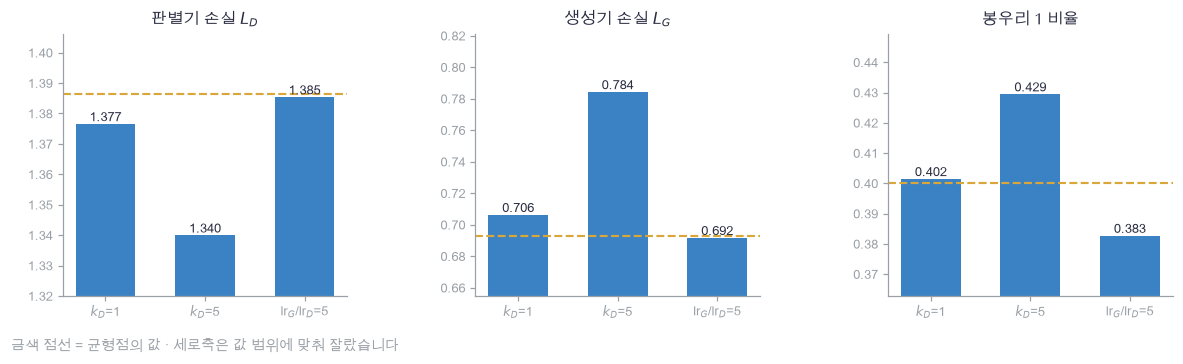

In [76]:
plot_variant_bars(variant_names, {"판별기 손실 $L_D$": (variant_d, 2 * np.log(2)),
                                  "생성기 손실 $L_G$": (variant_g, np.log(2)),
                                  "봉우리 1 비율": (variant_fraction, MIX2_PI[0])})

🔍 **확인** · $k_D=5$ 는 판별기 손실을 균형값 $2\log2$ 아래로 끌어내리고 생성기 손실을 $\log2$ 위로 밀어 올립니다. 판별기가 이기고 있다는 뜻입니다. 그런데도 봉우리 1 의 비율은 0.43 으로 기준(0.40)과 크게 다르지 않습니다.
판별기를 다섯 배 자주 갱신하는 비싼 계산으로 얻은 것이 거의 없다는 점이 중요합니다. 이 작은 문제에서는 $k_D=1$ 로 충분하고, 그래서 이 노트북의 기본값이 1 입니다.
두 학습률의 비를 5 로 벌린 설정은 두 손실이 균형값에 가장 가깝지만 봉우리 1 의 비율이 0.38 로 조금 치우칩니다. 어느 쪽을 더 세게 미느냐가 **누가 이기는가**를 바꾸고, 그것이 다시 coverage 를 흔듭니다.
29번에서 다룰 WGAN 과 gradient penalty 는 바로 이 균형을 덜 예민하게 만들려는 시도입니다. 다만 penalty 항이 "기울기의 기울기"를 요구해서 손 backward 로는 감당하기 어렵고, 13번의 자동미분 엔진이나 PyTorch 가 필요합니다.

### ✏️ 준비도 질문 · 다음으로 가기 전, 네 가지를 따로 확인합니다

🔑 표시가 붙은 절의 내용만으로 답할 수 있어야 합니다.

- **설명:** 판별기와 생성기의 목적이 어떻게 반대인지, minimax 식 대신 non-saturating 식을 쓰는 이유를 말할 수 있나요? → 1절
- **수식:** 생성기 기울기가 $\partial L_G/\partial a\to dX_{fake}\to d\theta_G$ 로 이어지는 연쇄를 쓰고, 각 단계에서 무엇을 버리는지 말할 수 있나요? 최적 판별기 $D^*$와 균형점의 두 손실값을 유도할 수 있나요? → 2·3절
- **구현:** `mlp_backward` 를 두 번 불러 생성기 기울기를 만들고, 교대 갱신 루프에서 두 Adam 상태를 따로 두는 코드를 직접 쓸 수 있나요? → 2·3절
- **변형:** 판별기를 약하게 만들면 무엇이 달라지는지, 그 변화를 봉우리별 개수로 어떻게 재는지 설명할 수 있나요? → 4·5절

다음은 29번(설계만)과 [32 score](32_score_matching.ipynb)입니다. 이 노트북은 밀도를 쓰지 않고 **두 번째 신경망**을 심판으로 세웠고, 32번은 같은 문제를 밀도의 기울기를 직접 배우는 쪽으로 풉니다. 두 길의 차이를 나란히 놓고 보면 생성 모형의 지도가 보입니다.

📎 [Goodfellow 등, 2014](https://arxiv.org/abs/1406.2661)가 이 노트북의 원논문입니다. 1절의 두 손실과 3절의 최적 판별기·$2\log2-2\,\mathrm{JSD}$ 유도가 그 논문 3절의 내용이고, non-saturating 식은 그 논문에서 "실제로는 이쪽을 쓴다"고 밝힌 변형입니다. 이 노트북의 혼합 예제와 PCA 좌표 실험은 설명을 위해 새로 구성한 것이며 원논문의 재현 실험이 아닙니다.